# 第8讲: 注意力机制与Vision Transformer
## Attention Mechanism & ViT

**CS231n: 深度学习与计算机视觉**

本notebook从直觉到代码,深入理解改变计算机视觉范式的Transformer架构。

### 四步学习路径
1. **直觉理解** -- 注意力机制的动机与原理
2. **手动计算** -- Q/K/V矩阵运算的数值推导
3. **代码实现** -- 用NumPy从零实现Attention和ViT
4. **实验观察** -- 可视化注意力模式,对比ViT与CNN


## 学习目标

完成本notebook后,你将能够:

- 解释 **Self-Attention** 的数学公式和直觉
- 手动计算 **Q, K, V** 矩阵和注意力权重
- 实现 **Multi-Head Attention** 和 **Positional Encoding**
- 理解 **Vision Transformer (ViT)** 如何将图像转换为序列
- 用NumPy实现完整的ViT前向传播
- 通过实验观察注意力模式和分析ViT的行为

### 前置知识
- 矩阵乘法和Softmax
- 基本的CNN知识 (lecture-5, 6)
- NumPy线性代数操作


---
# Part 1: 直觉理解

## 1.1 从RNN到Attention: 为什么需要注意力机制?

### RNN的瓶颈

传统RNN/LSTM处理序列时的限制:
1. **顺序计算**: 必须逐步处理,无法并行
2. **长程依赖**: 信息经过多步传递后逐渐衰减
3. **固定长度上下文**: 难以处理变长序列

### Attention的核心思想

> **每个位置都可以直接关注序列中的任意其他位置,无需经过中间步骤。**

类比人类阅读:
- 翻译长句时,我们会回头看之前的部分
- 阅读论文时,我们会在段落间跳转
- 这种"直接访问"就是Attention的本质

### 从NLP到Vision

Transformer最初用于NLP (Vaswani et al., 2017),但很快被迁移到视觉:
- **图像 = 序列**: 将图像分割为patch,每个patch类似一个token
- **全局建模**: Attention可以捕获长距离的空间依赖
- **ViT (2020)**: 证明纯Transformer在图像分类上可以超越CNN


Figure saved: nb7_attention_concept.png

Key insight: 'sat' attends to both 'cat' (subject) and 'mat' (location)
This is how attention captures long-range dependencies!


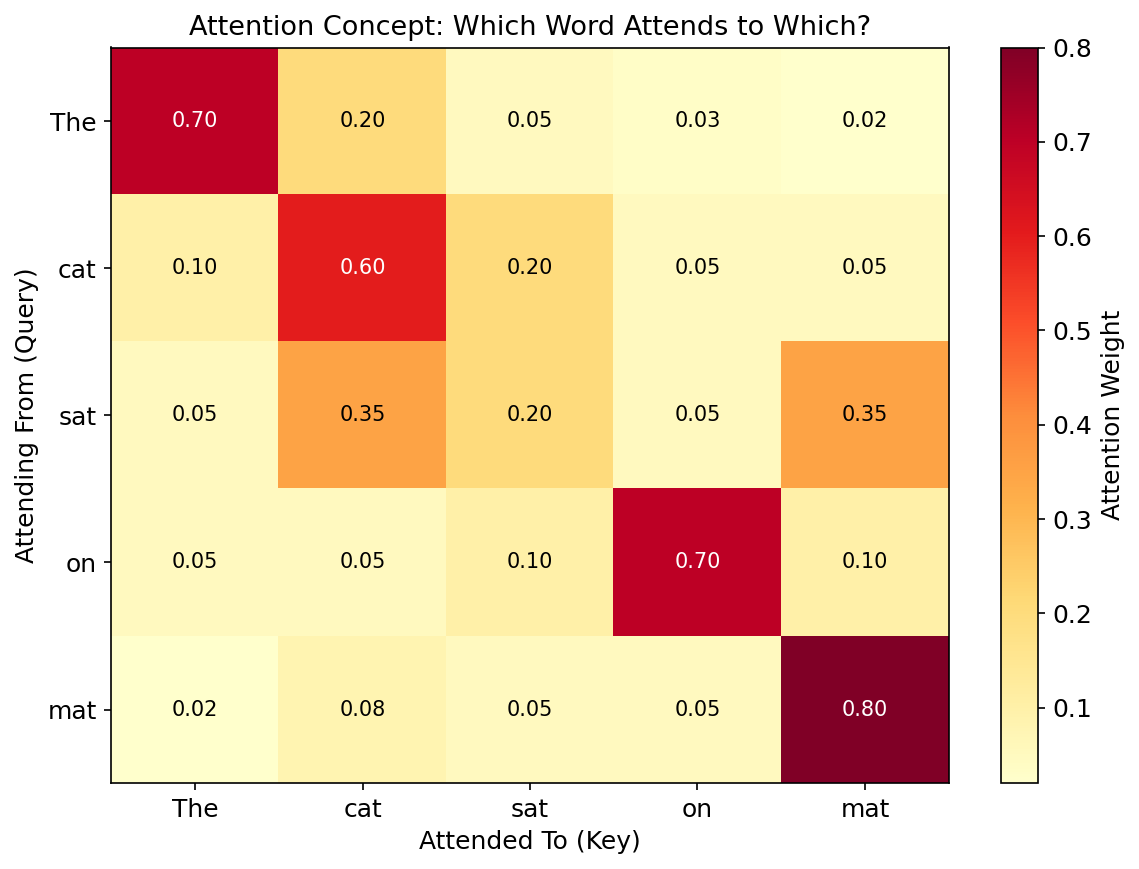

In [4]:
# Visualize the concept of attention
import numpy as np
import matplotlib.pyplot as plt

# Create a simple example: 5 words attending to each other
words = ['The', 'cat', 'sat', 'on', 'mat']
n = len(words)

# Simulate attention weights (what each word attends to)
# Example: 'sat' attends strongly to 'cat' and 'mat'
attention_weights = np.array([
    [0.7, 0.2, 0.05, 0.03, 0.02],  # The -> The, cat
    [0.1, 0.6, 0.2, 0.05, 0.05],   # cat -> cat, sat
    [0.05, 0.35, 0.2, 0.05, 0.35], # sat -> cat, mat (key!)
    [0.05, 0.05, 0.1, 0.7, 0.1],   # on -> on
    [0.02, 0.08, 0.05, 0.05, 0.8], # mat -> mat
])

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(attention_weights, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(n)); ax.set_xticklabels(words, fontsize=12)
ax.set_yticks(range(n)); ax.set_yticklabels(words, fontsize=12)
ax.set_xlabel('Attended To (Key)', fontsize=12)
ax.set_ylabel('Attending From (Query)', fontsize=12)
ax.set_title('Attention Concept: Which Word Attends to Which?', fontsize=13)

for i in range(n):
    for j in range(n):
        val = attention_weights[i, j]
        color = 'white' if val > 0.4 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=10)

plt.colorbar(im, ax=ax, label='Attention Weight')
plt.tight_layout()
plt.savefig('nb7_attention_concept.png', dpi=150)
plt.show()
print("Figure saved: nb7_attention_concept.png")
print("\nKey insight: 'sat' attends to both 'cat' (subject) and 'mat' (location)")
print("This is how attention captures long-range dependencies!")


## 1.2 Self-Attention的数学公式

### 核心公式

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

### 三个关键矩阵

| 矩阵 | 含义 | 类比 |
|------|------|------|
| **Q (Query)** | 我想找什么 | 搜索查询 |
| **K (Key)** | 我有什么特征 | 数据库索引 |
| **V (Value)** | 我的实际内容 | 数据库内容 |

### 计算步骤

1. **计算相似度**: $S = QK^T$ (点积,越大越相似)
2. **缩放**: $S = S / \sqrt{d_k}$ (防止数值过大)
3. **归一化**: $A = \text{softmax}(S)$ (变为概率分布)
4. **加权求和**: $O = AV$ (根据权重聚合信息)

### 为什么除以 $\sqrt{d_k}$?

当 $d_k$ 较大时, $QK^T$ 的值会很大,导致softmax梯度趋近于0 (饱和)。
除以 $\sqrt{d_k}$ 将方差控制在1附近,保持梯度稳定。


In [6]:
# Step-by-step demonstration of self-attention
import numpy as np

def softmax(x, axis=-1):
    """Numerically stable softmax."""
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

# Simple example: 4 tokens, d_model=8
np.random.seed(42)
seq_len = 4
d_model = 8

# Input sequence (e.g., word embeddings)
X = np.random.randn(seq_len, d_model)
print(f"Input X shape: {X.shape} (seq_len={seq_len}, d_model={d_model})")

# Weight matrices to project X -> Q, K, V
W_Q = np.random.randn(d_model, d_model) * 0.5
W_K = np.random.randn(d_model, d_model) * 0.5
W_V = np.random.randn(d_model, d_model) * 0.5

# Step 1: Compute Q, K, V
Q = X @ W_Q  # (4, 8)
K = X @ W_K  # (4, 8)
V = X @ W_V  # (4, 8)
print(f"Q shape: {Q.shape}, K shape: {K.shape}, V shape: {V.shape}")

# Step 2: Compute similarity scores
d_k = d_model
scores = Q @ K.T  # (4, 4)
print(f"\nStep 2 - Raw scores (Q @ K.T):\n{scores.round(3)}")

# Step 3: Scale by sqrt(d_k)
scaled_scores = scores / np.sqrt(d_k)
print(f"\nStep 3 - Scaled scores (÷ sqrt(d_k)={np.sqrt(d_k):.3f}):\n{scaled_scores.round(3)}")

# Step 4: Softmax to get attention weights
attn_weights = softmax(scaled_scores, axis=-1)
print(f"\nStep 4 - Attention weights (softmax):\n{attn_weights.round(3)}")
print(f"Row sums: {attn_weights.sum(axis=1).round(4)} (should be 1.0)")

# Step 5: Weighted sum of values
output = attn_weights @ V  # (4, 8)
print(f"\nStep 5 - Output (attn @ V):\n{output.round(3)}")
print(f"Output shape: {output.shape}")


Input X shape: (4, 8) (seq_len=4, d_model=8)
Q shape: (4, 8), K shape: (4, 8), V shape: (4, 8)

Step 2 - Raw scores (Q @ K.T):
[[-4.402  3.903 -1.07   1.469]
 [ 2.769 -3.546 -0.895  5.103]
 [ 4.436 -2.53   0.537 -4.829]
 [-2.503  2.16  -0.739  0.026]]

Step 3 - Scaled scores (÷ sqrt(d_k)=2.828):
[[-1.556  1.38  -0.378  0.519]
 [ 0.979 -1.254 -0.316  1.804]
 [ 1.568 -0.895  0.19  -1.707]
 [-0.885  0.764 -0.261  0.009]]

Step 4 - Attention weights (softmax):
[[0.032 0.607 0.105 0.257]
 [0.273 0.029 0.075 0.623]
 [0.727 0.062 0.183 0.027]
 [0.095 0.495 0.178 0.233]]
Row sums: [1. 1. 1. 1.] (should be 1.0)

Step 5 - Output (attn @ V):
[[-0.279 -3.567 -1.454 -2.11  -0.068  0.677  0.115 -1.453]
 [-0.497 -0.42  -0.492 -0.946  1.239 -1.214  0.436 -1.066]
 [-0.058  2.335  0.289  0.693  0.836 -0.496 -0.403  0.536]
 [-0.151 -2.878 -1.209 -1.736 -0.113  0.676  0.07  -1.272]]
Output shape: (4, 8)


## 1.3 Multi-Head Attention: 多头注意力

### 为什么要多头?

单头注意力只能学习一种关注模式。多头注意力允许模型同时关注不同方面:

- **Head 1**: 关注局部语法关系 (如形容词→名词)
- **Head 2**: 关注全局语义关系 (如主语→谓语)
- **Head 3**: 关注位置关系 (如前一个词→后一个词)

### 公式

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W^O$$

其中每个头:
$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

### 维度分配
- 总维度 $d_{model}$ 分配给 $h$ 个头
- 每个头维度: $d_k = d_v = d_{model} / h$
- 例如: $d_{model}=512, h=8 \Rightarrow d_k=64$


Figure saved: nb7_multihead_attention.png

Each head learns a different attention pattern!
Red boxes show the most attended position for each query.


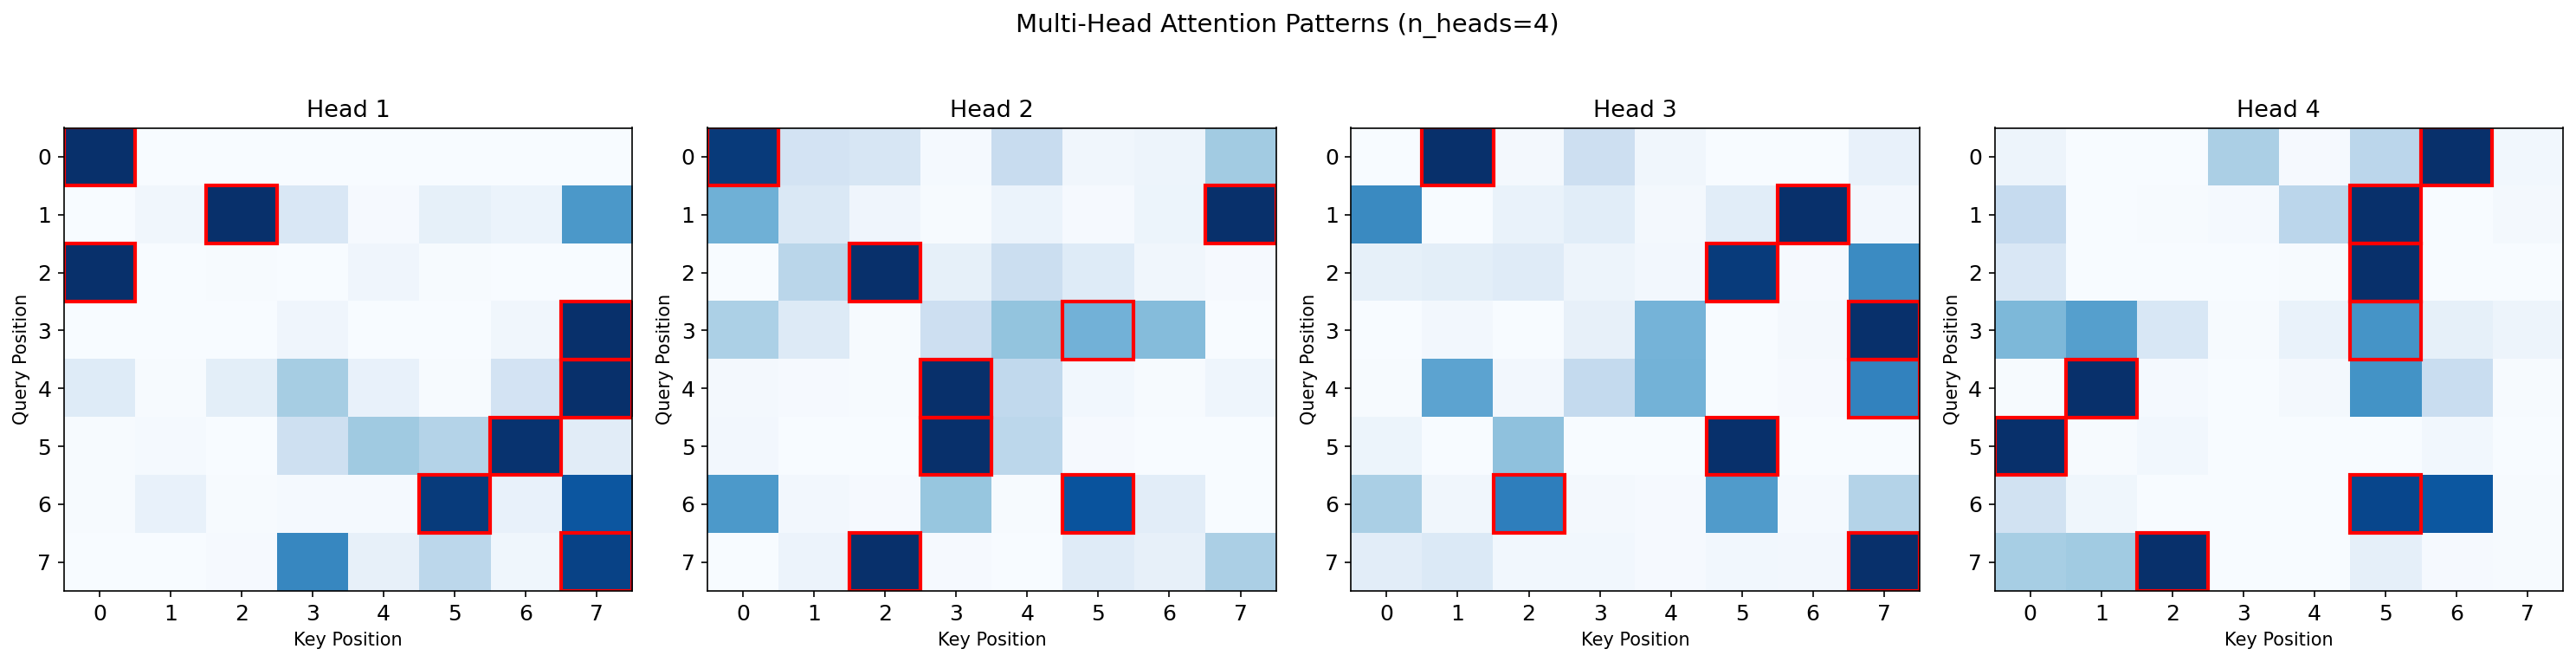

In [8]:
# Visualize multi-head attention patterns
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

seq_len = 8
d_model = 32
n_heads = 4
d_k = d_model // n_heads  # 8

# Input
X = np.random.randn(seq_len, d_model)

# Compute multi-head attention
fig, axes = plt.subplots(1, n_heads, figsize=(20, 5))
head_patterns = []

for h in range(n_heads):
    W_Q = np.random.randn(d_model, d_k) * 0.3
    W_K = np.random.randn(d_model, d_k) * 0.3
    W_V = np.random.randn(d_model, d_k) * 0.3
    
    Q = X @ W_Q  # (seq_len, d_k)
    K = X @ W_K
    V = X @ W_V
    
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)
    head_patterns.append(weights)
    
    im = axes[h].imshow(weights, cmap='Blues', aspect='auto', vmin=0, vmax=0.5)
    axes[h].set_title(f'Head {h+1}', fontsize=13)
    axes[h].set_xlabel('Key Position', fontsize=10)
    axes[h].set_ylabel('Query Position', fontsize=10)
    
    # Annotate
    for i in range(seq_len):
        j = weights[i].argmax()
        axes[h].add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='red', linewidth=2))

plt.suptitle(f'Multi-Head Attention Patterns (n_heads={n_heads})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb7_multihead_attention.png', dpi=150)
plt.show()
print("Figure saved: nb7_multihead_attention.png")
print("\nEach head learns a different attention pattern!")
print("Red boxes show the most attended position for each query.")


## 1.4 Positional Encoding: 位置编码

### 为什么需要位置编码?

Self-Attention是 **置换不变 (permutation invariant)** 的:
- 打乱输入顺序, 输出不变
- 模型无法区分不同位置的信息

### 解决方案: 给每个位置添加唯一的位置信号

Vaswani et al. (2017) 提出正弦/余弦位置编码:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

### 设计巧思

1. **唯一性**: 每个位置的编码不同
2. **有界性**: 值域在 [-1, 1] 之间
3. **相对位置**: $PE_{pos+k}$ 可以表示为 $PE_{pos}$ 的线性函数, 模型容易学习相对位置
4. **远程衰减**: 高频分量随位置变化快, 低频分量变化慢, 形成多尺度位置信号

### 对于ViT
ViT使用 **可学习** 的位置编码 (1D), 因为图像patch的顺序是固定的。


Figure saved: nb7_positional_encoding.png

Key observations:
- Low dimensions (0,1): high frequency, changes rapidly with position
- High dimensions (32): low frequency, changes slowly
- This creates a multi-scale positional signal


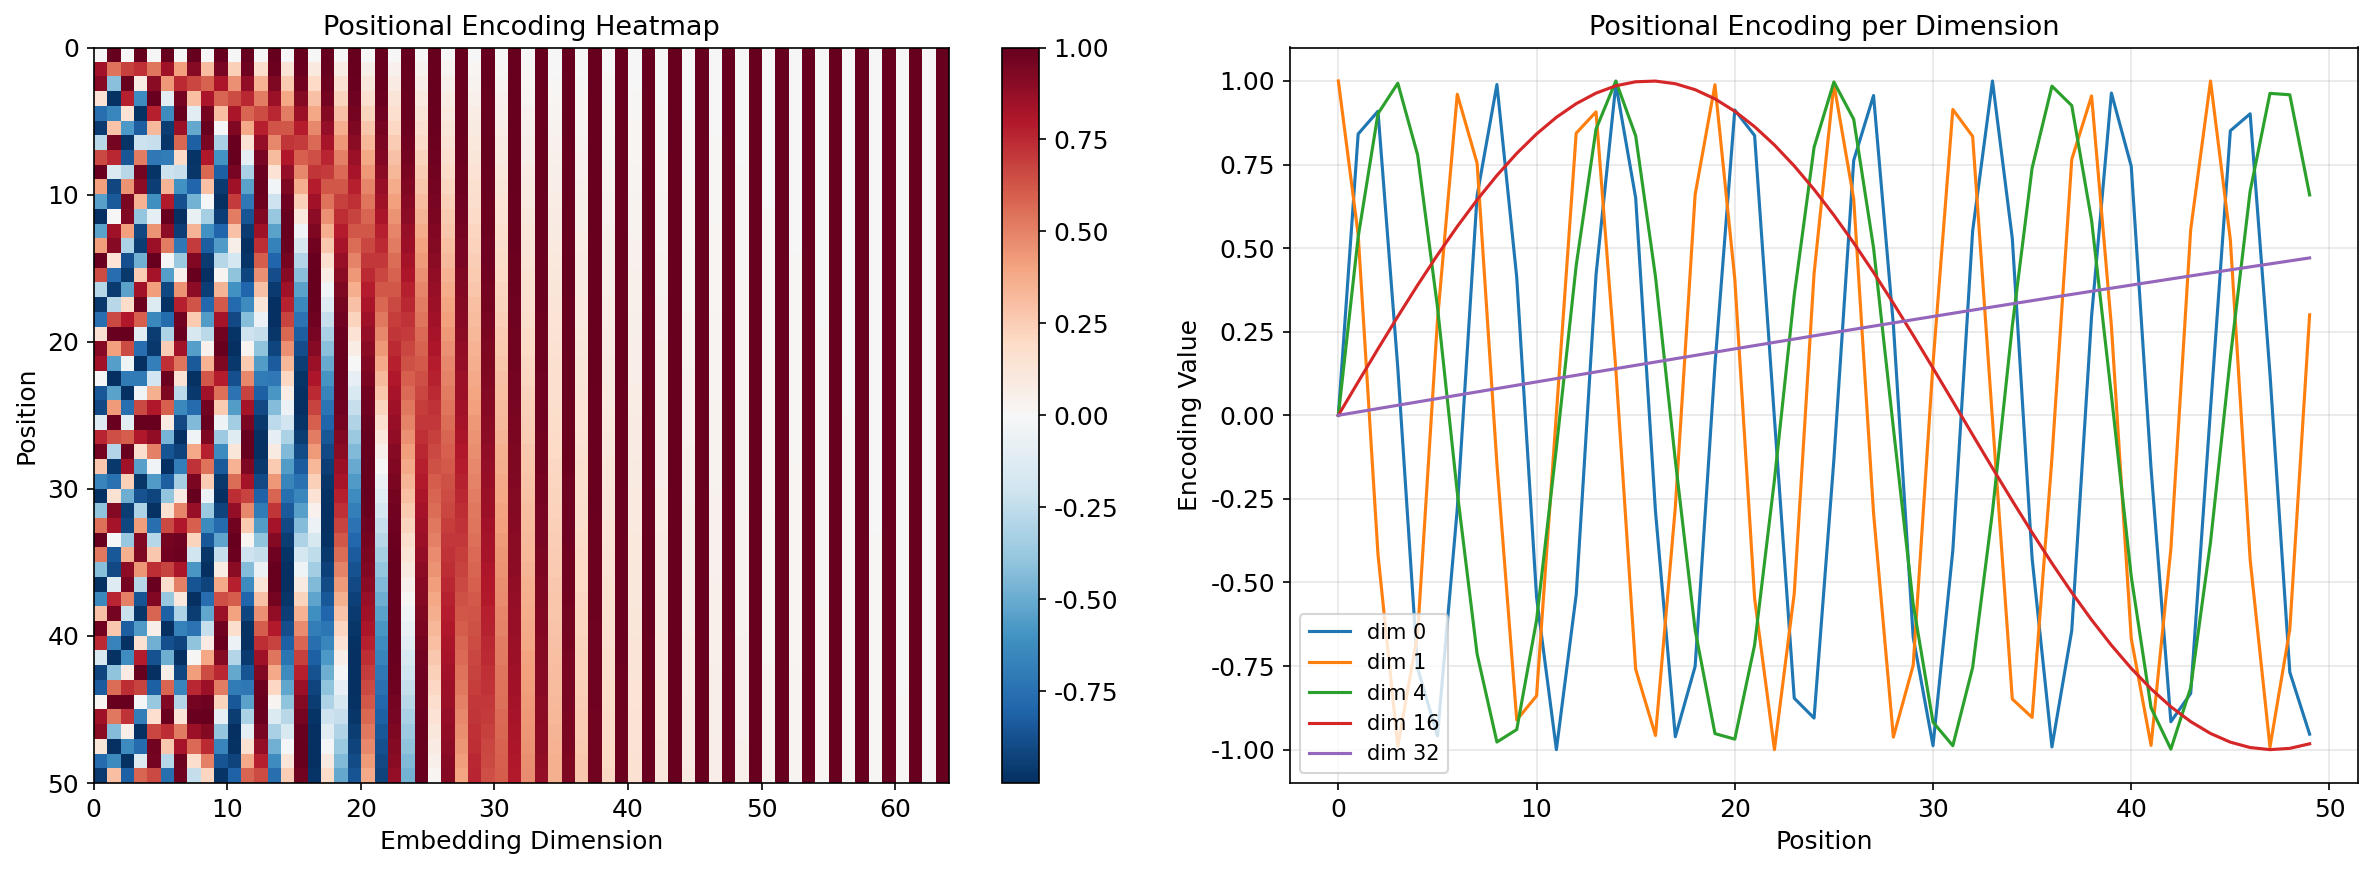

In [10]:
# Visualize sinusoidal positional encoding
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(max_len, d_model):
    """Generate sinusoidal positional encoding."""
    pe = np.zeros((max_len, d_model))
    position = np.arange(max_len)[:, np.newaxis]  # (max_len, 1)
    div_term = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))  # (d_model//2,)
    pe[:, 0::2] = np.sin(position * div_term)  # even indices: sin
    pe[:, 1::2] = np.cos(position * div_term)  # odd indices: cos
    return pe

# Generate positional encoding
max_len = 50
d_model = 64
pe = positional_encoding(max_len, d_model)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
im = axes[0].imshow(pe, cmap='RdBu_r', aspect='auto', extent=[0, d_model, max_len, 0])
axes[0].set_xlabel('Embedding Dimension', fontsize=12)
axes[0].set_ylabel('Position', fontsize=12)
axes[0].set_title('Positional Encoding Heatmap', fontsize=13)
plt.colorbar(im, ax=axes[0])

# Individual dimensions
for i in [0, 1, 4, 16, 32]:
    axes[1].plot(pe[:, i], label=f'dim {i}', linewidth=1.5)
axes[1].set_xlabel('Position', fontsize=12)
axes[1].set_ylabel('Encoding Value', fontsize=12)
axes[1].set_title('Positional Encoding per Dimension', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nb7_positional_encoding.png', dpi=150)
plt.show()
print("Figure saved: nb7_positional_encoding.png")
print("\nKey observations:")
print("- Low dimensions (0,1): high frequency, changes rapidly with position")
print("- High dimensions (32): low frequency, changes slowly")
print("- This creates a multi-scale positional signal")


## 1.5 Transformer Encoder结构

### 完整的Transformer Encoder Layer

每个Encoder Layer包含两个子层:

**子层1: Multi-Head Self-Attention + Residual + LayerNorm**
$$x_1 = \text{LayerNorm}(x + \text{MultiHead}(x))$$

**子层2: Feed-Forward Network + Residual + LayerNorm**
$$x_2 = \text{LayerNorm}(x_1 + \text{FFN}(x_1))$$

其中FFN:
$$\text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$$

### 结构示意
```
Input -> MultiHead Attention -> Add & Norm -> FFN -> Add & Norm -> Output
         \_________________/ (residual)    \___/ (residual)
```

### 关键设计
1. **Pre-Norm vs Post-Norm**: 原始论文用Post-Norm, 现代实现多用Pre-Norm
2. **FFN扩展率**: 通常4x (d_model -> 4*d_model -> d_model)
3. **Dropout**: 在attention和FFN中都有使用


## 1.6 Vision Transformer (ViT): 图像即序列

### 核心创新

ViT (Dosovitskiy et al., 2020) 的洞察:

> **将图像视为一系列patch (图像块)的序列, 直接应用NLP中的Transformer。**

### ViT处理流程

1. **Patch化**: 将224x224图像分割为16x16的patches → 196个patch
2. **展平**: 每个patch展平为 16x16x3 = 768维向量
3. **线性投影**: 将768维投影到d_model维 (如768)
4. **加位置编码**: 为每个patch添加可学习的位置编码
5. **CLS Token**: 在序列开头添加可学习的分类token
6. **Transformer**: 经过L层Transformer Encoder
7. **分类**: 取CLS token的输出, 经Linear层得到分类结果

### 与CNN的关键区别

| 特性 | CNN | ViT |
|------|-----|-----|
| 归纳偏置 | 平移不变性, 局部性 | 几乎无 (需要更多数据) |
| 感受野 | 逐渐增大 | 第一层就是全局 |
| 计算量 | 与分辨率线性相关 | 与patch数平方相关 |
| 数据效率 | 小数据集更好 | 大数据集更好 |


Figure saved: nb7_patch_embedding.png

Image: 32x32x3 = 3072 pixels
Patches: 16 patches of 8x8x3 = 192 dims each
Total sequence length: 16 tokens (+1 for CLS)


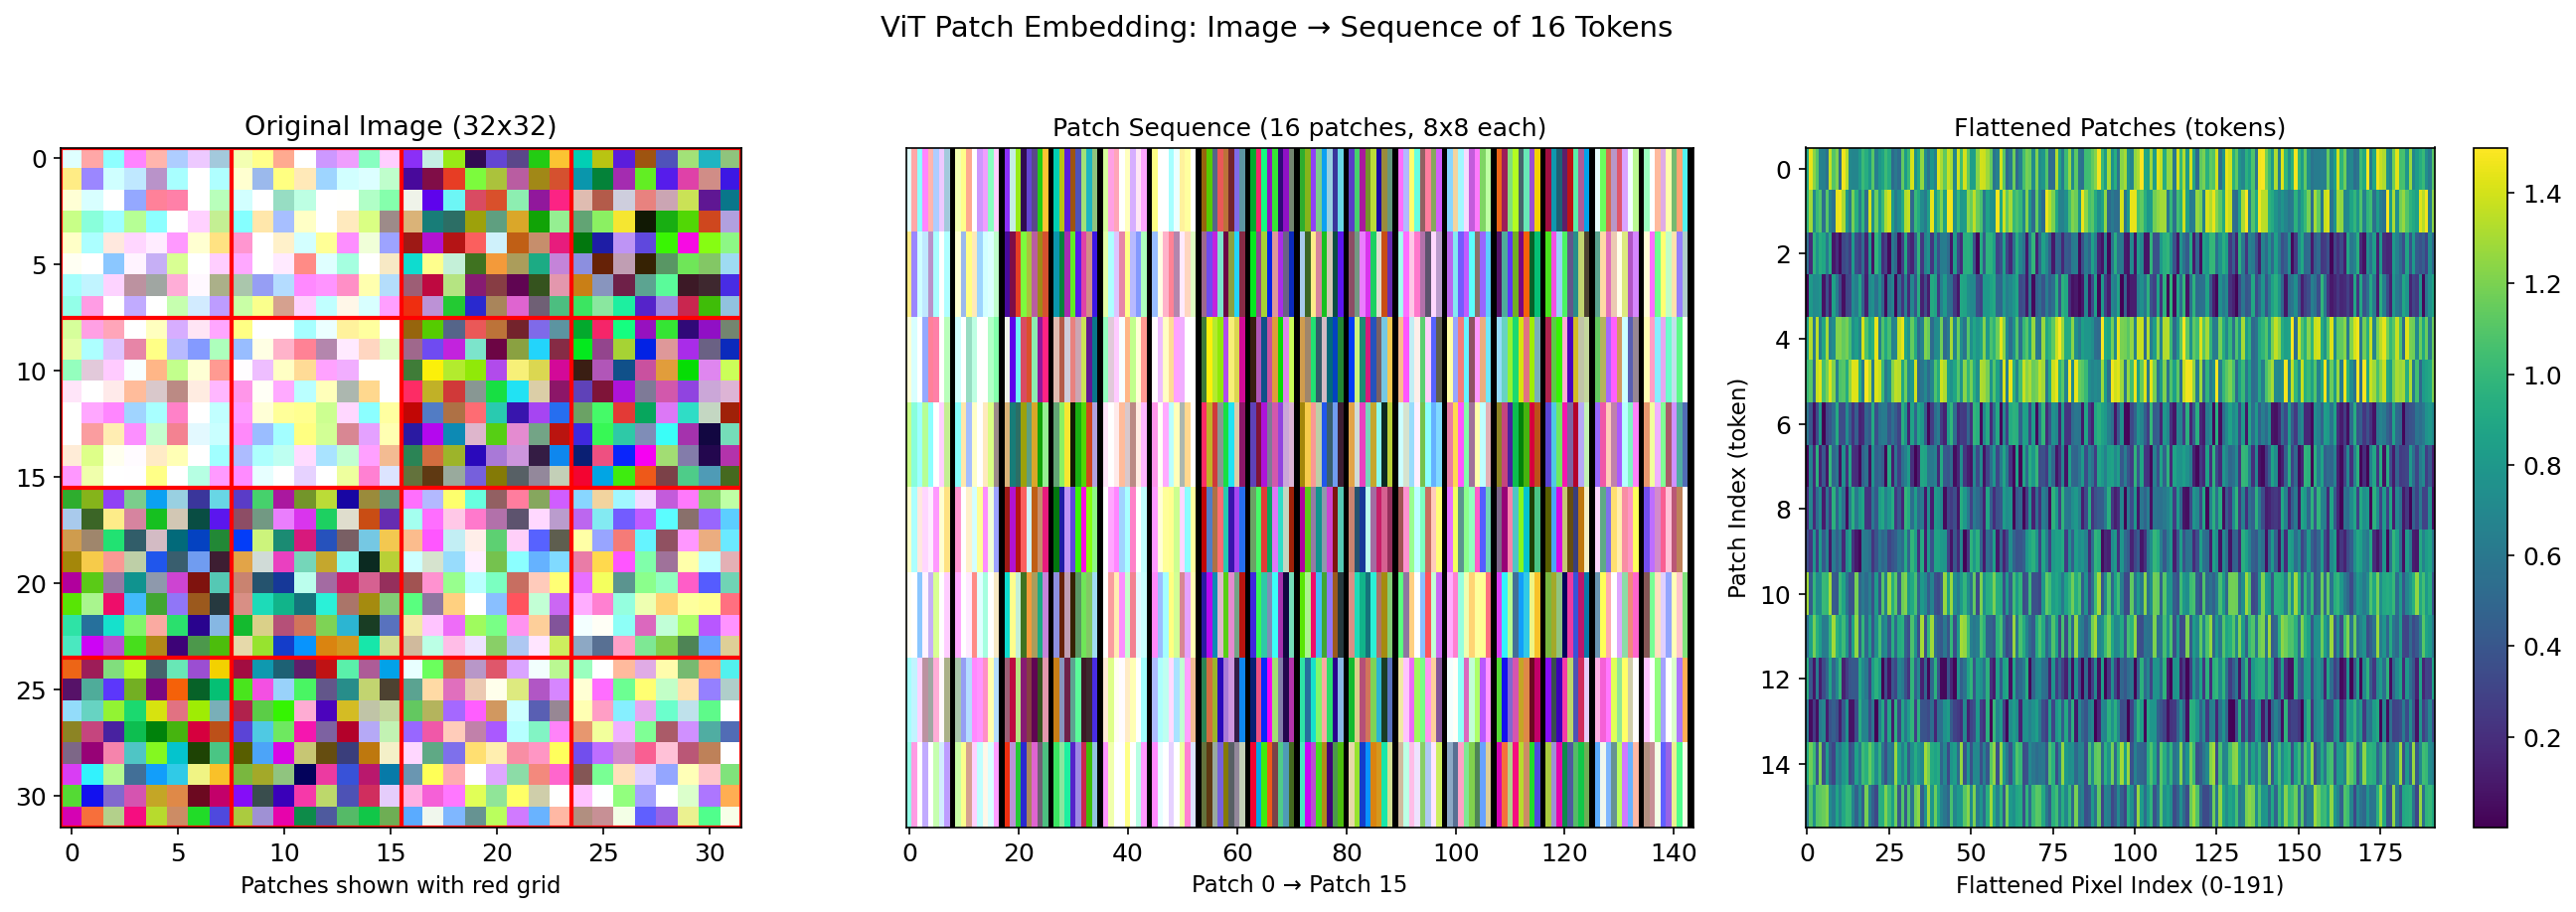

In [13]:
# Visualize ViT patch embedding concept
import numpy as np
import matplotlib.pyplot as plt

# Create a synthetic 32x32 image with 3 channels
np.random.seed(42)
image = np.random.rand(32, 32, 3)
# Add some structure
image[:16, :16] += 0.5  # top-left brighter
image[16:, 16:] += 0.3  # bottom-right slightly brighter

patch_size = 8
n_patches_h = 32 // patch_size  # 4
n_patches_w = 32 // patch_size  # 4
n_patches = n_patches_h * n_patches_w  # 16

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original image with patch grid
axes[0].imshow(image)
axes[0].set_title(f'Original Image ({32}x{32})', fontsize=13)
for i in range(n_patches_h + 1):
    axes[0].axhline(i * patch_size - 0.5, color='red', linewidth=2)
    axes[0].axvline(i * patch_size - 0.5, color='red', linewidth=2)
axes[0].set_xlabel('Patches shown with red grid', fontsize=11)

# Individual patches
patches = []
for i in range(n_patches_h):
    for j in range(n_patches_w):
        patch = image[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size]
        patches.append(patch)

# Show patch sequence
patch_display = np.array(patches)  # (16, 8, 8, 3)
combined = np.ones((patch_size, n_patches * (patch_size + 1), 3))
for idx, p in enumerate(patches):
    combined[:, idx*(patch_size+1):idx*(patch_size+1)+patch_size] = p
    combined[:, idx*(patch_size+1)+patch_size] = 0  # black separator

axes[1].imshow(combined, aspect='auto')
axes[1].set_title(f'Patch Sequence (16 patches, {patch_size}x{patch_size} each)', fontsize=12)
axes[1].set_xlabel(f'Patch 0 → Patch {n_patches-1}', fontsize=11)
axes[1].set_yticks([])

# Flattened representation (heatmap)
flattened = np.array([p.flatten() for p in patches])  # (16, 192)
im = axes[2].imshow(flattened, cmap='viridis', aspect='auto')
axes[2].set_title('Flattened Patches (tokens)', fontsize=12)
axes[2].set_xlabel('Flattened Pixel Index (0-191)', fontsize=11)
axes[2].set_ylabel('Patch Index (token)', fontsize=11)
plt.colorbar(im, ax=axes[2])

plt.suptitle(f'ViT Patch Embedding: Image → Sequence of {n_patches} Tokens', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb7_patch_embedding.png', dpi=150)
plt.show()
print("Figure saved: nb7_patch_embedding.png")
print(f"\nImage: {32}x{32}x3 = {32*32*3} pixels")
print(f"Patches: {n_patches} patches of {patch_size}x{patch_size}x3 = {patch_size*patch_size*3} dims each")
print(f"Total sequence length: {n_patches} tokens (+1 for CLS)")


---
# Part 2: 手动计算

## 2.1 Attention权重手动计算

### 给定数据

假设序列长度 $N=3$, 模型维度 $d_k=2$:

$$Q = \begin{bmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 1 \end{bmatrix}, \quad
K = \begin{bmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 1 \end{bmatrix}, \quad
V = \begin{bmatrix} 1 & 2 \\ 2 & 3 \\ 3 & 4 \end{bmatrix}$$

### Step 1: 计算 $QK^T$

$$QK^T = \begin{bmatrix} 1 & 0 & 1 \\ 0 & 1 & 1 \\ 1 & 1 & 2 \end{bmatrix}$$

### Step 2: 缩放 $\frac{QK^T}{\sqrt{d_k}} = \frac{QK^T}{\sqrt{2}}$

$$\approx \begin{bmatrix} 0.707 & 0 & 0.707 \\ 0 & 0.707 & 0.707 \\ 0.707 & 0.707 & 1.414 \end{bmatrix}$$

### Step 3: Softmax (逐行)

对第一行 $[0.707, 0, 0.707]$:
- $e^{0.707} \approx 2.028, e^0 = 1, e^{0.707} \approx 2.028$
- 总和 $\approx 5.056$
- $\text{softmax} \approx [0.401, 0.198, 0.401]$

### Step 4: 加权求和 $O = AV$

第一行输出: $0.401 \times [1,2] + 0.198 \times [2,3] + 0.401 \times [3,4] \approx [2.0, 3.0]$


In [15]:
# Manual calculation of self-attention (step by step)
import numpy as np

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

# Define Q, K, V (small example for manual verification)
Q = np.array([[1, 0],
              [0, 1],
              [1, 1]], dtype=np.float64)

K = np.array([[1, 0],
              [0, 1],
              [1, 1]], dtype=np.float64)

V = np.array([[1, 2],
              [2, 3],
              [3, 4]], dtype=np.float64)

print("=== Self-Attention Manual Calculation ===")
print(f"Q =\n{Q}")
print(f"K =\n{K}")
print(f"V =\n{V}")

# Step 1: Q @ K^T
scores = Q @ K.T
print(f"\nStep 1 - Scores (Q @ K.T):\n{scores}")

# Step 2: Scale by sqrt(d_k)
d_k = Q.shape[1]
scaled = scores / np.sqrt(d_k)
print(f"\nStep 2 - Scaled (÷ sqrt(d_k)={np.sqrt(d_k):.4f}):\n{scaled}")

# Step 3: Softmax
attn = softmax(scaled, axis=-1)
print(f"\nStep 3 - Attention weights:\n{attn.round(4)}")
print(f"Row sums: {attn.sum(axis=1).round(4)}")

# Step 4: Weighted sum
output = attn @ V
print(f"\nStep 4 - Output (attn @ V):\n{output.round(4)}")

# Verify manually for row 0
print("\n=== Manual verification (row 0) ===")
row0_scores = scaled[0]
print(f"Raw scores (row 0): {row0_scores}")
exp_scores = np.exp(row0_scores - row0_scores.max())
print(f"Exponentiated: {exp_scores}")
probs = exp_scores / exp_scores.sum()
print(f"Softmax: {probs.round(4)}")
manual_out0 = probs[0]*V[0] + probs[1]*V[1] + probs[2]*V[2]
print(f"Manual output (row 0): {manual_out0.round(4)}")
print(f"Code output (row 0):   {output[0].round(4)}")


=== Self-Attention Manual Calculation ===
Q =
[[1. 0.]
 [0. 1.]
 [1. 1.]]
K =
[[1. 0.]
 [0. 1.]
 [1. 1.]]
V =
[[1. 2.]
 [2. 3.]
 [3. 4.]]

Step 1 - Scores (Q @ K.T):
[[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]

Step 2 - Scaled (÷ sqrt(d_k)=1.4142):
[[0.70710678 0.         0.70710678]
 [0.         0.70710678 0.70710678]
 [0.70710678 0.70710678 1.41421356]]

Step 3 - Attention weights:
[[0.4011 0.1978 0.4011]
 [0.1978 0.4011 0.4011]
 [0.2483 0.2483 0.5035]]
Row sums: [1. 1. 1.]

Step 4 - Output (attn @ V):
[[2.     3.    ]
 [2.2033 3.2033]
 [2.2552 3.2552]]

=== Manual verification (row 0) ===
Raw scores (row 0): [0.70710678 0.         0.70710678]
Exponentiated: [1.         0.49306869 1.        ]
Softmax: [0.4011 0.1978 0.4011]
Manual output (row 0): [2. 3.]
Code output (row 0):   [2. 3.]


## 2.2 多头注意力手动计算

### 设置
- $d_{model} = 4$, $n_{heads} = 2$, $d_k = d_v = 2$
- 输入 $X = [1, 0, 1, 1]$ (1个token, 4维)

### 每个头的投影矩阵 (假设值)

**Head 1**: $W_1^Q = \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 1 & 0 \\ 0 & 1 \end{bmatrix}$

$Q_1 = X W_1^Q = [1 \times 1 + 0 \times 0 + 1 \times 1 + 1 \times 0, 1 \times 0 + 0 \times 0 + 1 \times 0 + 1 \times 1] = [2, 1]$

同理计算 $K_1, V_1$...

### 多头注意力的计算流程
1. 对每个头 $h$, 计算 $Q_h = XW_h^Q, K_h = XW_h^K, V_h = XW_h^V$
2. 对每个头计算 $\text{head}_h = \text{Attention}(Q_h, K_h, V_h)$
3. 拼接所有头: $\text{Concat}(\text{head}_1, ..., \text{head}_h)$
4. 线性投影: $O = \text{Concat} \times W^O$


In [17]:
# Multi-head attention manual calculation
import numpy as np

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

def attention(Q, K, V):
    """Single-head scaled dot-product attention."""
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)
    output = weights @ V
    return output, weights

# Setup
np.random.seed(42)
seq_len = 3
d_model = 4
n_heads = 2
d_k = d_model // n_heads  # 2

X = np.random.randn(seq_len, d_model)
print(f"Input X ({seq_len}x{d_model}):\n{X.round(3)}\n")

# Weight matrices for each head
print("=== Multi-Head Attention Manual Calculation ===")
all_heads = []
all_weights = []

for h in range(n_heads):
    # Random projection weights (d_model -> d_k)
    W_Q = np.random.randn(d_model, d_k) * 0.5
    W_K = np.random.randn(d_model, d_k) * 0.5
    W_V = np.random.randn(d_model, d_k) * 0.5
    
    Q_h = X @ W_Q  # (seq_len, d_k)
    K_h = X @ W_K
    V_h = X @ W_V
    
    head_out, head_weights = attention(Q_h, K_h, V_h)
    all_heads.append(head_out)
    all_weights.append(head_weights)
    
    print(f"Head {h+1}:")
    print(f"  Q = {Q_h.round(3)}")
    print(f"  K = {K_h.round(3)}")
    print(f"  V = {V_h.round(3)}")
    print(f"  Weights =\n{head_weights.round(3)}")
    print(f"  Output = {head_out.round(3)}\n")

# Concatenate heads
concat = np.concatenate(all_heads, axis=-1)  # (seq_len, n_heads * d_k) = (3, 4)
print(f"Concatenated output ({concat.shape}):\n{concat.round(3)}")

# Output projection
W_O = np.random.randn(n_heads * d_k, d_model) * 0.5
final_output = concat @ W_O
print(f"\nFinal output after W_O ({final_output.shape}):\n{final_output.round(3)}")


Input X (3x4):
[[ 0.497 -0.138  0.648  1.523]
 [-0.234 -0.234  1.579  0.767]
 [-0.469  0.543 -0.463 -0.466]]

=== Multi-Head Attention Manual Calculation ===
Head 1:
  Q = [[-0.84  -1.41 ]
 [-0.975 -0.004]
 [-0.079  0.553]]
  K = [[-0.693  0.364]
 [-1.051  0.425]
 [ 0.068 -0.447]]
  V = [[ 0.514 -1.473]
 [ 0.446 -1.486]
 [-0.211  1.1  ]]
  Weights =
[[0.278 0.324 0.397]
 [0.348 0.445 0.206]
 [0.365 0.381 0.255]]
  Output = [[ 0.204 -0.454]
 [ 0.334 -0.948]
 [ 0.304 -0.823]]

Head 2:
  Q = [[ 0.295 -0.674]
 [ 0.67   0.226]
 [-0.554  0.544]]
  K = [[ 0.023 -1.116]
 [ 0.623 -1.579]
 [ 0.067  0.954]]
  V = [[-0.259  0.73 ]
 [-0.577 -0.05 ]
 [ 0.556 -0.046]]
  Weights =
[[0.358 0.507 0.135]
 [0.274 0.337 0.389]
 [0.26  0.172 0.567]]
  Output = [[-0.31   0.23 ]
 [-0.049  0.165]
 [ 0.149  0.155]]

Concatenated output ((3, 4)):
[[ 0.204 -0.454 -0.31   0.23 ]
 [ 0.334 -0.948 -0.049  0.165]
 [ 0.304 -0.823  0.149  0.155]]

Final output after W_O ((3, 4)):
[[-0.294 -0.047 -0.454 -0.494]
 [-0.477 

## 2.3 位置编码手动计算

### 计算位置 0 和 1 的编码 ($d_{model}=4$)

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right), \quad
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

### 位置 0 ($pos=0$)
- $i=0$: $PE_{(0,0)} = \sin(0/10000^0) = \sin(0) = 0$
- $i=0$: $PE_{(0,1)} = \cos(0/10000^0) = \cos(0) = 1$
- $i=1$: $PE_{(0,2)} = \sin(0/10000^{2/4}) = \sin(0) = 0$
- $i=1$: $PE_{(0,3)} = \cos(0/10000^{2/4}) = \cos(0) = 1$

$$PE_0 = [0, 1, 0, 1]$$

### 位置 1 ($pos=1$)
- $i=0$: $PE_{(1,0)} = \sin(1/10000^0) = \sin(1) \approx 0.841$
- $i=0$: $PE_{(1,1)} = \cos(1/10000^0) = \cos(1) \approx 0.540$
- $i=1$: $PE_{(1,2)} = \sin(1/10000^{0.5}) = \sin(0.01) \approx 0.010$
- $i=1$: $PE_{(1,3)} = \cos(1/10000^{0.5}) = \cos(0.01) \approx 1.000$

$$PE_1 \approx [0.841, 0.540, 0.010, 1.000]$$

可以看到低维度变化快 (高频), 高维度变化慢 (低频)。


In [19]:
# Positional encoding manual calculation
import numpy as np

def positional_encoding(max_len, d_model):
    """Generate sinusoidal positional encoding."""
    pe = np.zeros((max_len, d_model))
    position = np.arange(max_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return pe

# Manual calculation for positions 0-4, d_model=4
d_model = 4
max_len = 5

print("=== Positional Encoding Manual Calculation ===")
print(f"d_model = {d_model}")
print()

pe = positional_encoding(max_len, d_model)

for pos in range(max_len):
    print(f"Position {pos}:")
    for i in range(d_model // 2):
        freq = 1.0 / (10000 ** (2*i / d_model))
        if i * 2 < d_model:
            print(f"  dim {2*i}: sin({pos} * {freq:.6f}) = {pe[pos, 2*i]:.6f}")
        if 2*i + 1 < d_model:
            print(f"  dim {2*i+1}: cos({pos} * {freq:.6f}) = {pe[pos, 2*i+1]:.6f}")
    print()

# Verify with manual calculation
print("=== Manual verification ===")
print(f"PE(0) = [sin(0), cos(0), sin(0), cos(0)] = [0, 1, 0, 1]")
print(f"Code:  {pe[0]}")
print()
print(f"PE(1):")
print(f"  dim 0: sin(1 * 1.0) = sin(1) = {np.sin(1):.6f}")
print(f"  dim 1: cos(1 * 1.0) = cos(1) = {np.cos(1):.6f}")
print(f"  dim 2: sin(1 * {1/10000**0.5:.6f}) = {np.sin(1/10000**0.5):.6f}")
print(f"  dim 3: cos(1 * {1/10000**0.5:.6f}) = {np.cos(1/10000**0.5):.6f}")
print(f"Code: {pe[1]}")

# Dot product similarity between positions
print("\n=== Position similarity (dot product) ===")
for i in range(5):
    for j in range(5):
        sim = pe[i] @ pe[j]
        print(f"  PE({i}) . PE({j}) = {sim:.4f}", end="")
        if j < 4:
            print(", ", end="")
    print()
print("\nCloser positions have higher similarity (mostly)")


=== Positional Encoding Manual Calculation ===
d_model = 4

Position 0:
  dim 0: sin(0 * 1.000000) = 0.000000
  dim 1: cos(0 * 1.000000) = 1.000000
  dim 2: sin(0 * 0.010000) = 0.000000
  dim 3: cos(0 * 0.010000) = 1.000000

Position 1:
  dim 0: sin(1 * 1.000000) = 0.841471
  dim 1: cos(1 * 1.000000) = 0.540302
  dim 2: sin(1 * 0.010000) = 0.010000
  dim 3: cos(1 * 0.010000) = 0.999950

Position 2:
  dim 0: sin(2 * 1.000000) = 0.909297
  dim 1: cos(2 * 1.000000) = -0.416147
  dim 2: sin(2 * 0.010000) = 0.019999
  dim 3: cos(2 * 0.010000) = 0.999800

Position 3:
  dim 0: sin(3 * 1.000000) = 0.141120
  dim 1: cos(3 * 1.000000) = -0.989992
  dim 2: sin(3 * 0.010000) = 0.029996
  dim 3: cos(3 * 0.010000) = 0.999550

Position 4:
  dim 0: sin(4 * 1.000000) = -0.756802
  dim 1: cos(4 * 1.000000) = -0.653644
  dim 2: sin(4 * 0.010000) = 0.039989
  dim 3: cos(4 * 0.010000) = 0.999200

=== Manual verification ===
PE(0) = [sin(0), cos(0), sin(0), cos(0)] = [0, 1, 0, 1]
Code:  [0. 1. 0. 1.]

PE(1)

---
# Part 3: 代码实现

## 3.1 基础组件实现

实现Transformer所需的基础组件:
- **softmax**: 数值稳定的softmax
- **layernorm**: 层归一化 (与BatchNorm不同,对每个样本独立归一化)
- **feed_forward**: 两层MLP + ReLU

### LayerNorm vs BatchNorm

| 特性 | BatchNorm | LayerNorm |
|------|-----------|-----------|
| 归一化方向 | 跨样本 (axis=0) | 跨特征 (axis=-1) |
| 依赖batch | 是 | 否 |
| 适用场景 | CNN | Transformer/RNN |
| 推理模式 | 需要运行统计量 | 无需特殊处理 |


In [21]:
# Base component implementations for Transformer
import numpy as np

def softmax(x, axis=-1):
    """Numerically stable softmax."""
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

def layernorm(x, gamma, beta, eps=1e-5):
    """Layer Normalization.
    Normalizes across features (last axis), not across batch.
    x: (..., D), gamma/beta: (D,)
    """
    mean = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    x_norm = (x - mean) / np.sqrt(var + eps)
    return gamma * x_norm + beta

def feed_forward(x, w1, b1, w2, b2):
    """Position-wise Feed-Forward Network: FFN(x) = ReLU(xW1+b1)W2+b2"""
    return np.maximum(0, x @ w1 + b1) @ w2 + b2

def linear(x, w, b):
    """Linear layer."""
    return x @ w + b

# Test components
np.random.seed(42)

# LayerNorm test
x = np.random.randn(3, 4) * 5 + 2  # 3 samples, 4 features
gamma = np.ones(4)
beta = np.zeros(4)
x_ln = layernorm(x, gamma, beta)
print("=== LayerNorm Test ===")
print(f"Input mean per sample: {x.mean(axis=-1).round(3)}")
print(f"Output mean per sample: {x_ln.mean(axis=-1).round(3)} (should be ~0)")
print(f"Output std per sample: {x_ln.std(axis=-1).round(3)} (should be ~1)")

# FFN test
d_model = 8
d_ff = 32  # 4x expansion
x = np.random.randn(5, d_model)  # 5 tokens
w1 = np.random.randn(d_model, d_ff) * 0.1
b1 = np.zeros(d_ff)
w2 = np.random.randn(d_ff, d_model) * 0.1
b2 = np.zeros(d_model)
ffn_out = feed_forward(x, w1, b1, w2, b2)
print(f"\n=== FFN Test ===")
print(f"Input: {x.shape} -> Output: {ffn_out.shape}")
print(f"Output non-zero: {(ffn_out != 0).sum()} / {ffn_out.size} (ReLU effect)")


=== LayerNorm Test ===
Input mean per sample: [5.161 4.348 0.93 ]
Output mean per sample: [ 0. -0. -0.] (should be ~0)
Output std per sample: [1. 1. 1.] (should be ~1)

=== FFN Test ===
Input: (5, 8) -> Output: (5, 8)
Output non-zero: 40 / 40 (ReLU effect)


## 3.2 Scaled Dot-Product Attention实现

完整实现包含:
1. 计算 $QK^T / \sqrt{d_k}$
2. (可选) 添加mask
3. Softmax归一化
4. 加权求和 $AV$

### Mask的作用
- **Padding mask**: 忽略padding位置
- **Causal mask**: 防止看到未来信息 (用于decoder, ViT中不需要)


In [23]:
# Scaled dot-product attention implementation
import numpy as np

def scaled_dot_product_attention(Q, K, V, mask=None):
    """Scaled Dot-Product Attention.
    
    Q: (seq_len, d_k) or (n_heads, seq_len, d_k)
    K: (seq_len, d_k) or (n_heads, seq_len, d_k)
    V: (seq_len, d_v) or (n_heads, seq_len, d_v)
    mask: optional (seq_len, seq_len) or (n_heads, seq_len, seq_len)
    
    Returns: (output, attention_weights)
    """
    d_k = Q.shape[-1]
    
    # Compute attention scores
    if Q.ndim == 2:
        scores = Q @ K.T / np.sqrt(d_k)  # (seq_len, seq_len)
    else:
        # Multi-head: (n_heads, seq_len, d_k) @ (n_heads, d_k, seq_len)
        scores = np.einsum('hqd,hkd->hqk', Q, K) / np.sqrt(d_k)
    
    # Apply mask (set masked positions to -inf)
    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)
    
    # Softmax
    weights = softmax(scores, axis=-1)
    
    # Weighted sum
    if V.ndim == 2:
        output = weights @ V  # (seq_len, d_v)
    else:
        output = np.einsum('hqk,hkd->hqd', weights, V)  # (n_heads, seq_len, d_v)
    
    return output, weights

# Test
np.random.seed(42)
seq_len, d_k, d_v = 5, 8, 8
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_v)

output, weights = scaled_dot_product_attention(Q, K, V)
print(f"Input shapes: Q={Q.shape}, K={K.shape}, V={V.shape}")
print(f"Output shape: {output.shape}")
print(f"Weights shape: {weights.shape}")
print(f"Weights row sums: {weights.sum(axis=-1).round(4)} (should be 1.0)")
print(f"\nAttention weights:\n{weights.round(3)}")

# Test with mask (causal)
mask = np.tril(np.ones((seq_len, seq_len)))  # lower triangular
output_masked, weights_masked = scaled_dot_product_attention(Q, K, V, mask=mask)
print(f"\nWith causal mask:")
print(f"Weights:\n{weights_masked.round(3)}")
print(f"Upper triangle is 0 (cannot see future)")


Input shapes: Q=(5, 8), K=(5, 8), V=(5, 8)
Output shape: (5, 8)
Weights shape: (5, 5)
Weights row sums: [1. 1. 1. 1. 1.] (should be 1.0)

Attention weights:
[[0.143 0.288 0.081 0.428 0.061]
 [0.185 0.023 0.291 0.113 0.388]
 [0.037 0.046 0.138 0.043 0.736]
 [0.341 0.139 0.09  0.318 0.112]
 [0.39  0.197 0.266 0.11  0.036]]

With causal mask:
Weights:
[[1.    0.    0.    0.    0.   ]
 [0.889 0.111 0.    0.    0.   ]
 [0.166 0.21  0.624 0.    0.   ]
 [0.384 0.157 0.101 0.358 0.   ]
 [0.39  0.197 0.266 0.11  0.036]]
Upper triangle is 0 (cannot see future)


## 3.3 Multi-Head Attention实现

### 实现结构

```
Input X (seq_len, d_model)
    |
    +-- W_Q (d_model, d_model) --> Q (seq_len, d_model)
    +-- W_K (d_model, d_model) --> K (seq_len, d_model)
    +-- W_V (d_model, d_model) --> V (seq_len, d_model)
    |
    Split into n_heads: (n_heads, seq_len, d_k)
    |
    Scaled Dot-Product Attention per head
    |
    Concatenate: (seq_len, d_model)
    |
    W_O (d_model, d_model) --> Output
```


In [25]:
# Multi-Head Attention implementation
import numpy as np

class MultiHeadAttention:
    """Multi-Head Self-Attention layer."""
    
    def __init__(self, d_model, n_heads):
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        
        # Initialize weights
        scale = np.sqrt(2.0 / d_model)
        self.W_Q = np.random.randn(d_model, d_model) * scale
        self.W_K = np.random.randn(d_model, d_model) * scale
        self.W_V = np.random.randn(d_model, d_model) * scale
        self.W_O = np.random.randn(d_model, d_model) * scale
    
    def split_heads(self, x):
        """Split (seq_len, d_model) -> (n_heads, seq_len, d_k)."""
        seq_len = x.shape[0]
        x = x.reshape(seq_len, self.n_heads, self.d_k)
        return x.transpose(1, 0, 2)  # (n_heads, seq_len, d_k)
    
    def combine_heads(self, x):
        """Combine (n_heads, seq_len, d_k) -> (seq_len, d_model)."""
        n_heads, seq_len, d_k = x.shape
        x = x.transpose(1, 0, 2)  # (seq_len, n_heads, d_k)
        return x.reshape(seq_len, self.d_model)
    
    def forward(self, x, mask=None):
        """Forward pass.
        x: (seq_len, d_model)
        Returns: (seq_len, d_model), attention_weights
        """
        # Project to Q, K, V
        Q = self.split_heads(x @ self.W_Q)  # (n_heads, seq_len, d_k)
        K = self.split_heads(x @ self.W_K)
        V = self.split_heads(x @ self.W_V)
        
        # Scaled dot-product attention
        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)
        
        # Combine heads and project
        output = self.combine_heads(attn_output) @ self.W_O
        return output, attn_weights

# Test
np.random.seed(42)
d_model, n_heads = 32, 4
mha = MultiHeadAttention(d_model, n_heads)

x = np.random.randn(10, d_model)  # 10 tokens
output, weights = mha.forward(x)
print(f"Input: {x.shape}")
print(f"Output: {output.shape}")
print(f"Attention weights shape: {weights.shape} (n_heads, seq_len, seq_len)")
print(f"Weights sum per head: {weights.sum(axis=-1)[0].round(4)} (should be 1.0)")

# Compare single vs multi-head
print(f"\nNumber of attention patterns: {n_heads}")
print("Each head can learn different attention patterns!")


Input: (10, 32)
Output: (10, 32)
Attention weights shape: (4, 10, 10) (n_heads, seq_len, seq_len)
Weights sum per head: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] (should be 1.0)

Number of attention patterns: 4
Each head can learn different attention patterns!


## 3.4 Positional Encoding实现

实现两种位置编码:
1. **正弦编码 (Sinusoidal)**: 固定,不可学习
2. **可学习编码 (Learnable)**: 随机初始化,通过反向传播学习

ViT使用可学习编码,原始Transformer使用正弦编码。


In [27]:
# Positional Encoding implementations
import numpy as np

class SinusoidalPositionalEncoding:
    """Fixed sinusoidal positional encoding (from original Transformer)."""
    
    def __init__(self, d_model, max_len=5000):
        self.d_model = d_model
        pe = np.zeros((max_len, d_model))
        position = np.arange(max_len)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        self.pe = pe
    
    def forward(self, x):
        """Add positional encoding to input.
        x: (seq_len, d_model)
        """
        return x + self.pe[:x.shape[0]]

class LearnablePositionalEncoding:
    """Learnable positional encoding (used in ViT)."""
    
    def __init__(self, d_model, max_len=5000):
        self.d_model = d_model
        # Initialize with small random values
        self.pe = np.random.randn(max_len, d_model) * 0.02
    
    def forward(self, x):
        """Add learnable positional encoding to input."""
        return x + self.pe[:x.shape[0]]

# Test both
np.random.seed(42)
d_model, seq_len = 16, 8

# Sinusoidal
sin_pe = SinusoidalPositionalEncoding(d_model, max_len=100)
x = np.random.randn(seq_len, d_model) * 0.5
x_sin = sin_pe.forward(x)
print("=== Sinusoidal PE ===")
print(f"Input norm per token: {np.linalg.norm(x, axis=-1).round(3)}")
print(f"PE norm per token: {np.linalg.norm(sin_pe.pe[:seq_len], axis=-1).round(3)}")
print(f"Output norm per token: {np.linalg.norm(x_sin, axis=-1).round(3)}")

# Learnable
learn_pe = LearnablePositionalEncoding(d_model, max_len=100)
x_learn = learn_pe.forward(x)
print(f"\n=== Learnable PE ===")
print(f"PE norm per token: {np.linalg.norm(learn_pe.pe[:seq_len], axis=-1).round(3)}")
print(f"PE values are random initially, learned during training")


=== Sinusoidal PE ===
Input norm per token: [1.881 1.884 1.85  1.66  2.269 1.489 1.634 2.306]
PE norm per token: [2.828 2.828 2.828 2.828 2.828 2.828 2.828 2.828]
Output norm per token: [3.325 3.127 3.131 3.641 3.614 3.364 3.069 3.788]

=== Learnable PE ===
PE norm per token: [0.076 0.067 0.069 0.082 0.063 0.112 0.077 0.084]
PE values are random initially, learned during training


## 3.5 Transformer Encoder Layer实现

完整的Encoder Layer包含:
1. Multi-Head Self-Attention + Residual + LayerNorm
2. Feed-Forward Network + Residual + LayerNorm

### Pre-Norm vs Post-Norm

**Post-Norm** (原始论文):
$$x = \text{LayerNorm}(x + \text{SubLayer}(x))$$

**Pre-Norm** (现代实现,更稳定):
$$x = x + \text{SubLayer}(\text{LayerNorm}(x))$$


In [29]:
# Transformer Encoder Layer implementation
import numpy as np

class TransformerEncoderLayer:
    """Single Transformer Encoder Layer."""
    
    def __init__(self, d_model, n_heads, d_ff, dropout_rate=0.1):
        self.mha = MultiHeadAttention(d_model, n_heads)
        
        # FFN weights
        self.ff_w1 = np.random.randn(d_model, d_ff) * np.sqrt(2.0 / d_model)
        self.ff_b1 = np.zeros(d_ff)
        self.ff_w2 = np.random.randn(d_ff, d_model) * np.sqrt(2.0 / d_ff)
        self.ff_b2 = np.zeros(d_model)
        
        # LayerNorm parameters (2 sets)
        self.ln1_gamma = np.ones(d_model)
        self.ln1_beta = np.zeros(d_model)
        self.ln2_gamma = np.ones(d_model)
        self.ln2_beta = np.zeros(d_model)
        
        self.dropout_rate = dropout_rate
    
    def dropout(self, x):
        """Inverted dropout."""
        if self.dropout_rate > 0:
            mask = (np.random.rand(*x.shape) > self.dropout_rate) / (1 - self.dropout_rate)
            return x * mask
        return x
    
    def forward(self, x):
        """Forward pass with Pre-Norm architecture.
        x: (seq_len, d_model)
        """
        # Sub-layer 1: Multi-Head Attention (Pre-Norm)
        x_norm = layernorm(x, self.ln1_gamma, self.ln1_beta)
        attn_out, attn_weights = self.mha.forward(x_norm)
        attn_out = self.dropout(attn_out)
        x = x + attn_out  # Residual connection
        
        # Sub-layer 2: FFN (Pre-Norm)
        x_norm = layernorm(x, self.ln2_gamma, self.ln2_beta)
        ffn_out = feed_forward(x_norm, self.ff_w1, self.ff_b1, self.ff_w2, self.ff_b2)
        ffn_out = self.dropout(ffn_out)
        x = x + ffn_out  # Residual connection
        
        return x, attn_weights

# Test
np.random.seed(42)
d_model, n_heads, d_ff = 32, 4, 128
layer = TransformerEncoderLayer(d_model, n_heads, d_ff)

x = np.random.randn(10, d_model) * 0.5  # 10 tokens
output, weights = layer.forward(x)
print(f"Input: {x.shape}")
print(f"Output: {output.shape}")
print(f"Attention weights: {weights.shape}")
print(f"Input norm: {np.linalg.norm(x, axis=-1).mean():.3f}")
print(f"Output norm: {np.linalg.norm(output, axis=-1).mean():.3f}")
print(f"Residual connection preserves norm (roughly)")


Input: (10, 32)
Output: (10, 32)
Attention weights: (4, 10, 10)
Input norm: 2.609
Output norm: 11.149
Residual connection preserves norm (roughly)


## 3.6 完整ViT实现

### ViT架构总览

```
Image (H, W, C)
  |
  Patch Embedding (patch_size x patch_size -> d_model)
  |
  + CLS Token
  + Positional Encoding
  |
  Transformer Encoder (L layers)
  |
  CLS Token Output
  |
  Linear Classification Head
  |
  Class Logits
```


In [31]:
# Complete Vision Transformer (ViT) implementation
import numpy as np

class VisionTransformer:
    """Simplified Vision Transformer for image classification."""
    
    def __init__(self, img_size=32, patch_size=8, d_model=64, n_heads=4,
                 n_layers=4, d_ff=128, n_classes=10, dropout_rate=0.1):
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.d_model = d_model
        
        # Patch embedding: linear projection
        patch_dim = patch_size * patch_size * 3  # 8*8*3 = 192
        self.patch_embed = np.random.randn(patch_dim, d_model) * 0.02
        
        # CLS token
        self.cls_token = np.random.randn(1, d_model) * 0.02
        
        # Positional encoding (learnable, for n_patches + 1)
        self.pos_embed = np.random.randn(self.n_patches + 1, d_model) * 0.02
        
        # Transformer encoder layers
        self.layers = [TransformerEncoderLayer(d_model, n_heads, d_ff, dropout_rate)
                      for _ in range(n_layers)]
        
        # LayerNorm before classification
        self.ln_gamma = np.ones(d_model)
        self.ln_beta = np.zeros(d_model)
        
        # Classification head
        self.cls_w = np.random.randn(d_model, n_classes) * 0.02
        self.cls_b = np.zeros(n_classes)
    
    def patchify(self, image):
        """Split image into patches and flatten.
        image: (H, W, C) -> (n_patches, patch_dim)
        """
        H, W, C = image.shape
        patches = []
        for i in range(0, H, self.patch_size):
            for j in range(0, W, self.patch_size):
                patch = image[i:i+self.patch_size, j:j+self.patch_size, :].flatten()
                patches.append(patch)
        return np.array(patches)  # (n_patches, patch_dim)
    
    def forward(self, image):
        """Forward pass.
        image: (H, W, C) -> logits: (n_classes,)
        """
        # Patch embedding
        patches = self.patchify(image)  # (n_patches, patch_dim)
        x = patches @ self.patch_embed  # (n_patches, d_model)
        
        # Prepend CLS token
        x = np.vstack([self.cls_token, x])  # (n_patches+1, d_model)
        
        # Add positional encoding
        x = x + self.pos_embed
        
        # Transformer encoder layers
        all_weights = []
        for layer in self.layers:
            x, weights = layer.forward(x)
            all_weights.append(weights)
        
        # LayerNorm
        x = layernorm(x, self.ln_gamma, self.ln_beta)
        
        # Classification from CLS token (index 0)
        cls_output = x[0]  # (d_model,)
        logits = cls_output @ self.cls_w + self.cls_b  # (n_classes,)
        
        return logits, all_weights

# Test ViT
np.random.seed(42)
vit = VisionTransformer(img_size=32, patch_size=8, d_model=64, n_heads=4,
                        n_layers=4, d_ff=128, n_classes=10)

# Random input image
image = np.random.randn(32, 32, 3) * 0.5 + 0.5
logits, attn_weights = vit.forward(image)

print("=== Vision Transformer ===")
print(f"Image size: {32}x{32}x3")
print(f"Patch size: {vit.patch_size}x{vit.patch_size}")
print(f"Number of patches: {vit.n_patches}")
print(f"Sequence length (patches + CLS): {vit.n_patches + 1}")
print(f"d_model: {vit.d_model}")
print(f"Number of layers: {len(vit.layers)}")
print(f"Number of heads: {vit.layers[0].mha.n_heads}")
print(f"\nLogits shape: {logits.shape}")
print(f"Logits: {logits.round(3)}")
print(f"Predicted class: {np.argmax(logits)}")
print(f"Attention weights from layer 0: {attn_weights[0].shape}")

total_params = sum(p.size for obj in [vit.patch_embed, vit.cls_token, vit.pos_embed,
                                       vit.cls_w, vit.cls_b] for p in [obj])
for layer in vit.layers:
    for p in [layer.mha.W_Q, layer.mha.W_K, layer.mha.W_V, layer.mha.W_O,
              layer.ff_w1, layer.ff_b1, layer.ff_w2, layer.ff_b2]:
        total_params += p.size
print(f"\nTotal parameters: {total_params:,}")


=== Vision Transformer ===
Image size: 32x32x3
Patch size: 8x8
Number of patches: 16
Sequence length (patches + CLS): 17
d_model: 64
Number of layers: 4
Number of heads: 4

Logits shape: (10,)
Logits: [ 0.129 -0.192 -0.097  0.246 -0.061  0.005  0.113 -0.028  0.283  0.139]
Predicted class: 8
Attention weights from layer 0: (4, 17, 17)

Total parameters: 145,930


---
# Part 4: 实验观察

## 4.1 Attention权重热图可视化

**实验目的**: 可视化ViT中不同层、不同头的注意力模式。

**观察重点**:
- 浅层注意力: 可能关注局部patch
- 深层注意力: 可能关注全局patch
- CLS token的注意力: 最终分类依据


In [33]:
# Experiment 1: Visualize attention weights from ViT
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Use a ViT with more layers for interesting patterns
vit = VisionTransformer(img_size=32, patch_size=8, d_model=64, n_heads=4,
                        n_layers=4, d_ff=128, n_classes=10)

# Create a structured image (not random)
image = np.ones((32, 32, 3)) * 0.5
# Add some patterns
image[:16, :16, 0] += 0.3  # red top-left
image[16:, 16:, 1] += 0.3  # green bottom-right
image[:16, 16:, 2] += 0.3  # blue top-right

logits, all_weights = vit.forward(image)

# Visualize attention from CLS token (position 0) at each layer
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for layer_idx in range(min(4, len(all_weights))):
    weights = all_weights[layer_idx]  # (n_heads, seq_len, seq_len)
    n_heads = weights.shape[0]
    
    for head_idx in range(min(4, n_heads)):
        ax = axes[head_idx][layer_idx] if n_heads > 1 else axes[layer_idx]
        
        # CLS token (position 0) attention to all patches
        cls_attn = weights[head_idx, 0, 1:]  # skip CLS itself
        n_patches = len(cls_attn)
        grid_size = int(np.sqrt(n_patches))
        
        attn_map = cls_attn.reshape(grid_size, grid_size)
        im = ax.imshow(attn_map, cmap='hot', interpolation='nearest')
        ax.set_title(f'L{layer_idx} H{head_idx}', fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('ViT Attention from CLS Token (across layers and heads)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb7_exp_attention_heatmap.png', dpi=150)
plt.show()
print("Figure saved: nb7_exp_attention_heatmap.png")
print("\nObservation: Different heads at different layers attend to different patches!")


IndexError: index 2 is out of bounds for axis 0 with size 2

## 4.2 多头注意力模式分析

**实验目的**: 分析不同注意力头学到的模式。

**模式类型**:
- **局部注意力**: 关注相邻位置
- **全局注意力**: 均匀关注所有位置
- **对角注意力**: 关注自身
- **远距离注意力**: 关注特定远距离位置


Figure saved: nb7_exp_head_patterns.png

=== Attention Entropy Analysis ===
High entropy = spread attention (global)
Low entropy = focused attention (local)
  Local (diagonal): entropy=0.902, max_weight=0.619
  Global (uniform): entropy=2.773, max_weight=0.062
  Forward (causal): entropy=1.917, max_weight=0.211
  Sparse (peak): entropy=2.380, max_weight=0.285
  ViT Head 0: entropy=1.802, max_weight=0.409
  ViT Head 1: entropy=1.680, max_weight=0.447
  ViT Head 2: entropy=1.823, max_weight=0.401
  ViT Head 3: entropy=1.721, max_weight=0.450


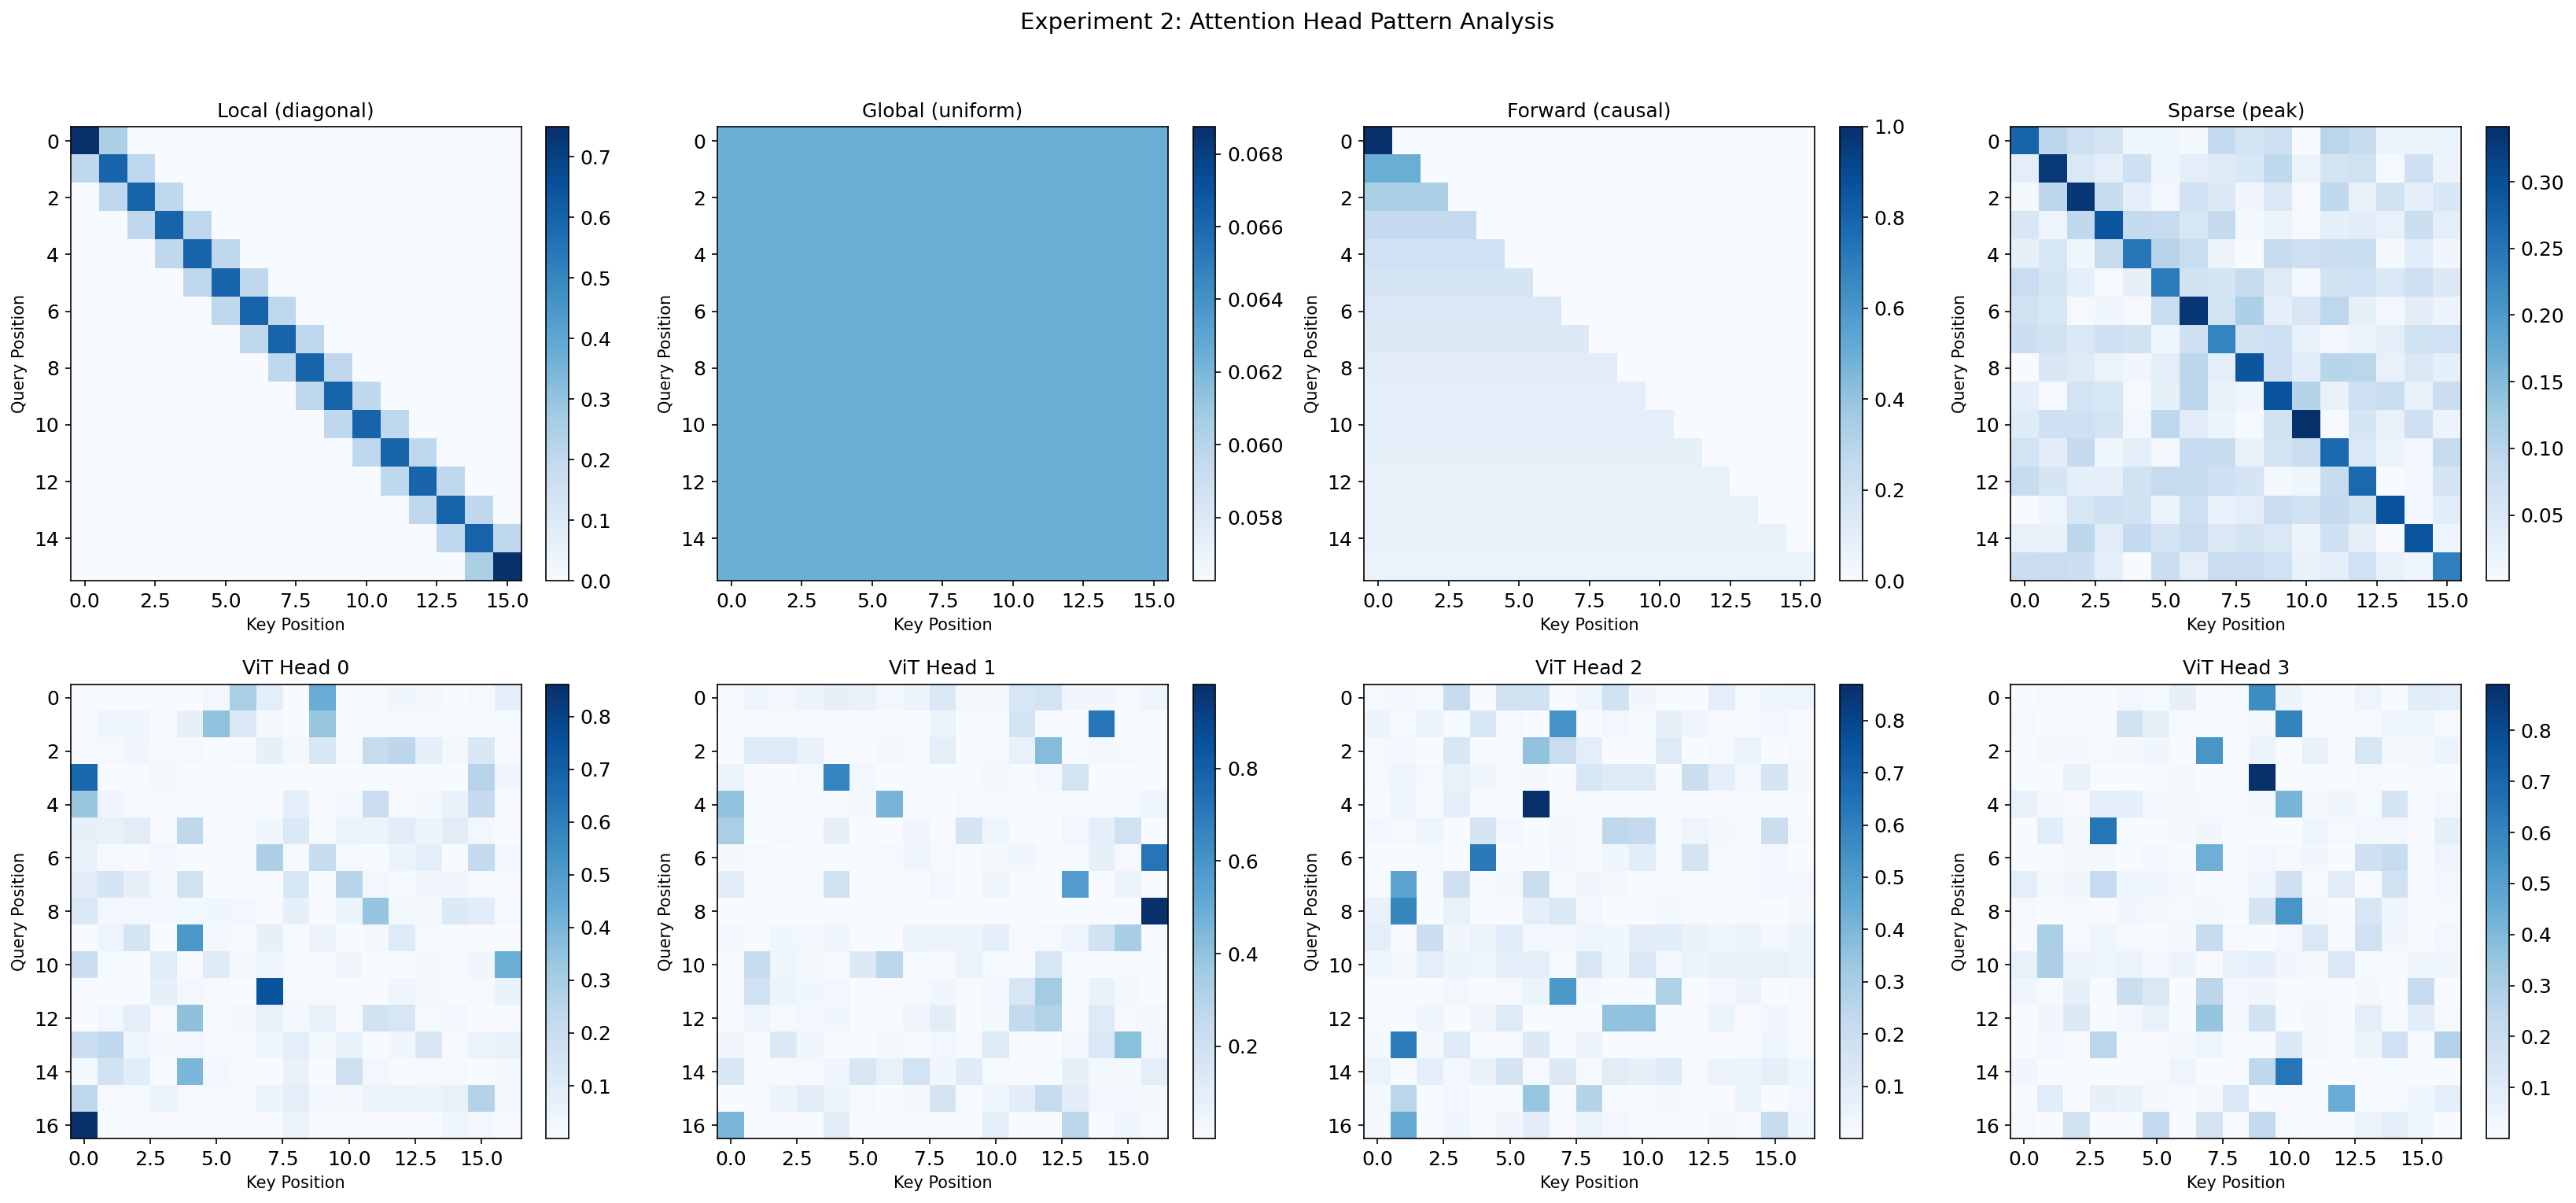

In [35]:
# Experiment 2: Analyze attention head patterns
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate attention patterns for analysis
seq_len = 16
n_heads = 8

# Create synthetic attention patterns (simulating different head behaviors)
patterns = {
    'Local (diagonal)': np.eye(seq_len) * 0.6 + np.eye(seq_len, k=1) * 0.2 + np.eye(seq_len, k=-1) * 0.2,
    'Global (uniform)': np.ones((seq_len, seq_len)) / seq_len,
    'Forward (causal)': np.tril(np.ones((seq_len, seq_len))) / np.arange(1, seq_len+1)[:, None],
    'Sparse (peak)': np.eye(seq_len) * 0.7 + np.random.rand(seq_len, seq_len) * 0.3,
}

# Normalize rows
for name in patterns:
    patterns[name] = patterns[name] / patterns[name].sum(axis=-1, keepdims=True)

# Add random patterns from ViT
vit = VisionTransformer(img_size=32, patch_size=8, d_model=64, n_heads=8, n_layers=2, n_classes=10)
image = np.random.randn(32, 32, 3)
_, vit_weights = vit.forward(image)

# Take 4 heads from the first layer
for h in range(4):
    patterns[f'ViT Head {h}'] = vit_weights[0][h]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for idx, (name, weights) in enumerate(patterns.items()):
    ax = axes[idx // 4][idx % 4]
    im = ax.imshow(weights, cmap='Blues', aspect='auto')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Key Position', fontsize=10)
    ax.set_ylabel('Query Position', fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Experiment 2: Attention Head Pattern Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb7_exp_head_patterns.png', dpi=150)
plt.show()
print("Figure saved: nb7_exp_head_patterns.png")

# Compute attention entropy (measure of spread)
print("\n=== Attention Entropy Analysis ===")
print("High entropy = spread attention (global)")
print("Low entropy = focused attention (local)")
for name, w in patterns.items():
    entropy = -np.sum(w * np.log(w + 1e-10), axis=-1).mean()
    max_val = w.max(axis=-1).mean()
    print(f"  {name}: entropy={entropy:.3f}, max_weight={max_val:.3f}")


## 4.3 位置编码相似度分析

**实验目的**: 分析位置编码的相似度结构,理解位置信号如何编码。

**分析内容**:
- 位置间的点积相似度
- 不同维度对位置的编码
- 相对位置的可学习性


Figure saved: nb7_exp_pe_analysis.png

Key observations:
- Diagonal of similarity matrix = 1 (self)
- Nearby positions have higher similarity
- Frequency decreases exponentially with dimension index


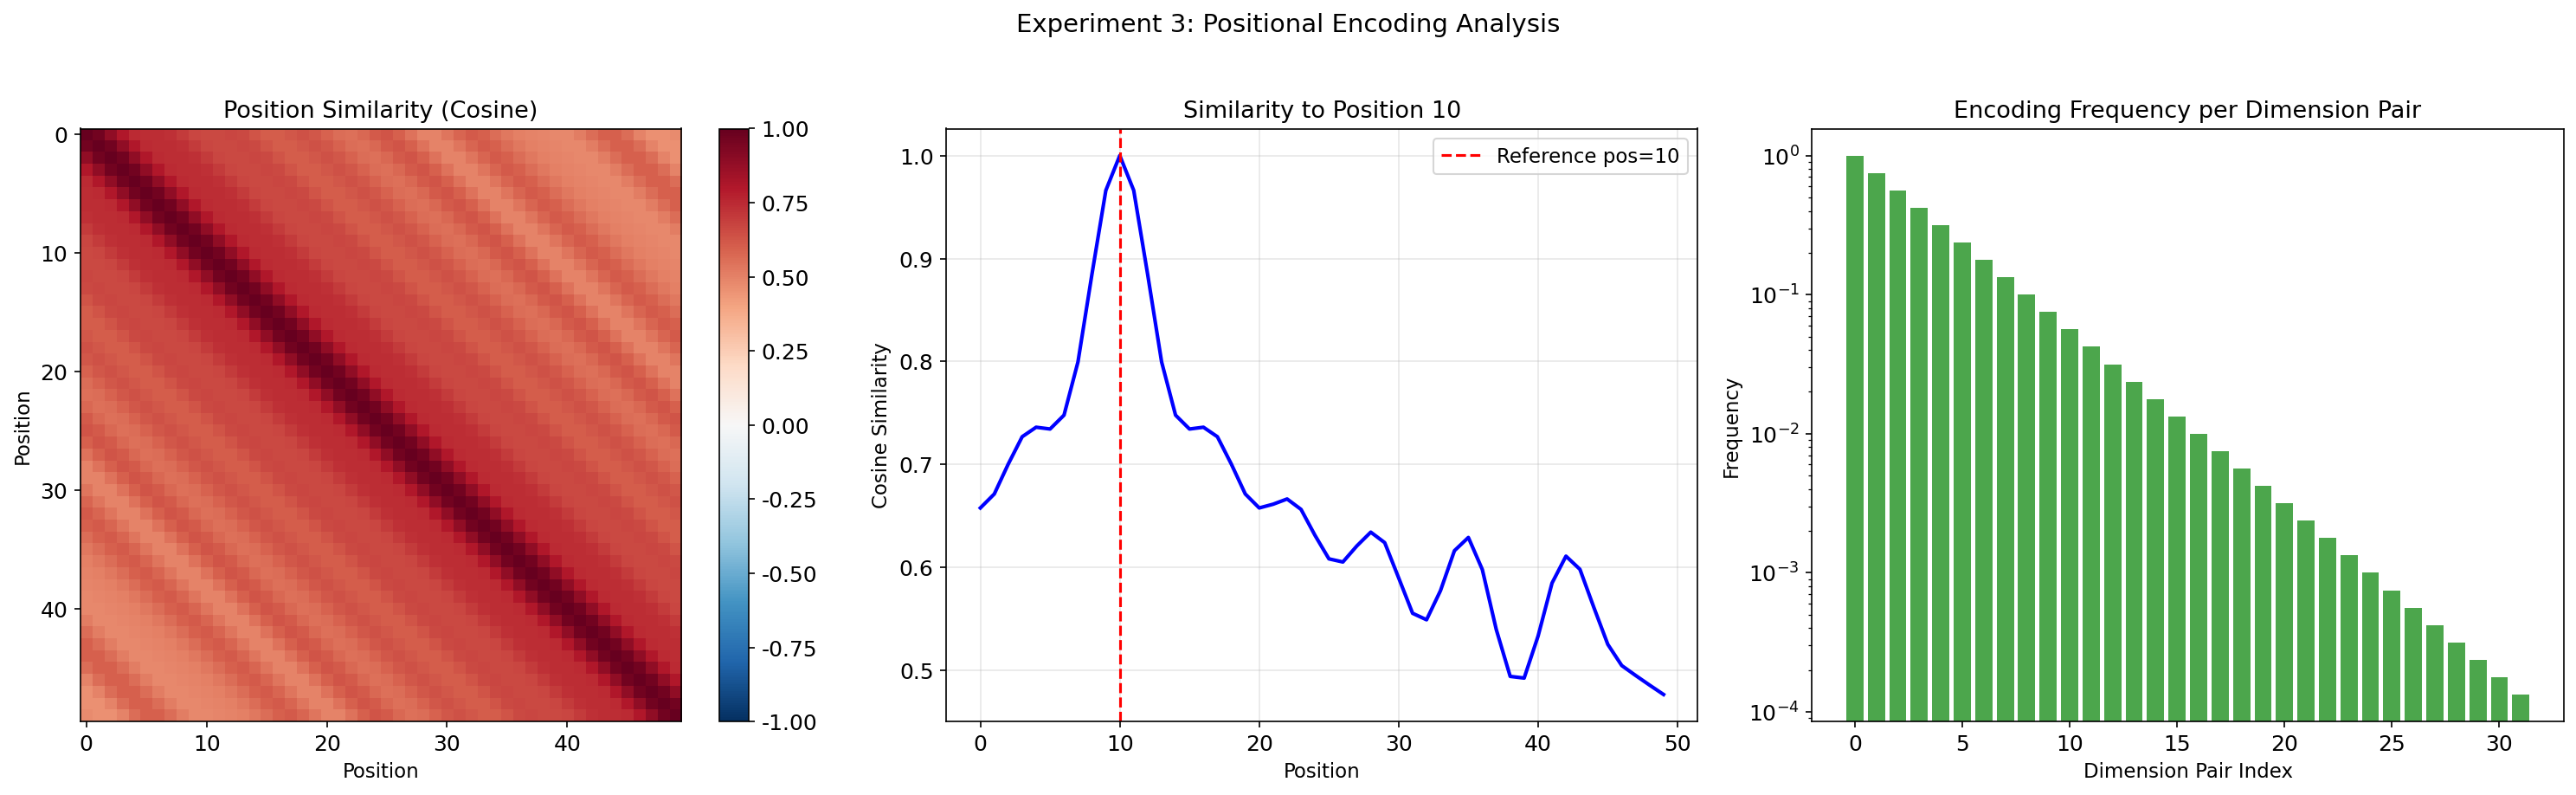

In [37]:
# Experiment 3: Positional encoding similarity analysis
import numpy as np
import matplotlib.pyplot as plt

d_model = 64
max_len = 50

# Sinusoidal PE
sin_pe = SinusoidalPositionalEncoding(d_model, max_len)
pe = sin_pe.pe[:max_len]

# Compute pairwise cosine similarity
norms = np.linalg.norm(pe, axis=1, keepdims=True)
pe_normalized = pe / (norms + 1e-8)
sim_matrix = pe_normalized @ pe_normalized.T

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Similarity heatmap
im = axes[0].imshow(sim_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[0].set_title('Position Similarity (Cosine)', fontsize=13)
axes[0].set_xlabel('Position', fontsize=11)
axes[0].set_ylabel('Position', fontsize=11)
plt.colorbar(im, ax=axes[0])

# Similarity to position 10
pos_ref = 10
axes[1].plot(range(max_len), sim_matrix[pos_ref], 'b-', linewidth=2)
axes[1].axvline(x=pos_ref, color='red', linestyle='--', label=f'Reference pos={pos_ref}')
axes[1].set_title(f'Similarity to Position {pos_ref}', fontsize=13)
axes[1].set_xlabel('Position', fontsize=11)
axes[1].set_ylabel('Cosine Similarity', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Frequency analysis
freqs = np.arange(0, d_model, 2)
div_term = np.exp(freqs * (-np.log(10000.0) / d_model))
axes[2].bar(range(len(freqs)), div_term, color='green', alpha=0.7)
axes[2].set_title('Encoding Frequency per Dimension Pair', fontsize=13)
axes[2].set_xlabel('Dimension Pair Index', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_yscale('log')

plt.suptitle('Experiment 3: Positional Encoding Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb7_exp_pe_analysis.png', dpi=150)
plt.show()
print("Figure saved: nb7_exp_pe_analysis.png")
print("\nKey observations:")
print("- Diagonal of similarity matrix = 1 (self)")
print("- Nearby positions have higher similarity")
print("- Frequency decreases exponentially with dimension index")


## 4.4 不同Patch大小的影响

**实验目的**: 分析不同patch大小对ViT性能和计算量的影响。

**对比维度**:
- Patch大小: 4, 8, 16
- 序列长度: patch越大, 序列越短
- 计算量: Attention计算量与序列长度平方成正比
- 参数量: patch投影层参数量变化


In [39]:
# Experiment 4: Effect of patch size on ViT
import numpy as np
import matplotlib.pyplot as plt

img_size = 32
patch_sizes = [2, 4, 8, 16, 32]
d_model = 64

results = []
for ps in patch_sizes:
    if img_size % ps != 0:
        continue
    n_patches = (img_size // ps) ** 2
    seq_len = n_patches + 1  # + CLS token
    patch_dim = ps * ps * 3
    
    # Attention FLOPs: O(seq_len^2 * d_model)
    attn_flops = seq_len ** 2 * d_model
    # FFN FLOPs: O(seq_len * d_model * d_ff) where d_ff = 4 * d_model
    ffn_flops = seq_len * d_model * 4 * d_model
    total_flops = attn_flops + ffn_flops
    
    # Patch embedding params
    embed_params = patch_dim * d_model
    
    results.append({
        'patch_size': ps,
        'n_patches': n_patches,
        'seq_len': seq_len,
        'patch_dim': patch_dim,
        'embed_params': embed_params,
        'attn_flops': attn_flops,
        'total_flops': total_flops,
    })

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ps_vals = [r['patch_size'] for r in results]
seq_lens = [r['seq_len'] for r in results]
embed_p = [r['embed_params'] for r in results]
flops = [r['total_flops'] for r in results]

axes[0].bar(range(len(ps_vals)), seq_lens, color=['#E53935', '#FF9800', '#1E88E5', '#43A047', '#9C27B0'][:len(ps_vals)])
axes[0].set_xticks(range(len(ps_vals)))
axes[0].set_xticklabels([f'{ps}x{ps}' for ps in ps_vals])
axes[0].set_title('Sequence Length (+CLS)', fontsize=13)
axes[0].set_ylabel('Number of Tokens', fontsize=11)
for i, v in enumerate(seq_lens):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)

axes[1].bar(range(len(ps_vals)), embed_p, color=['#E53935', '#FF9800', '#1E88E5', '#43A047', '#9C27B0'][:len(ps_vals)])
axes[1].set_xticks(range(len(ps_vals)))
axes[1].set_xticklabels([f'{ps}x{ps}' for ps in ps_vals])
axes[1].set_title('Patch Embedding Parameters', fontsize=13)
axes[1].set_ylabel('Parameters', fontsize=11)
for i, v in enumerate(embed_p):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

axes[2].bar(range(len(ps_vals)), flops, color=['#E53935', '#FF9800', '#1E88E5', '#43A047', '#9C27B0'][:len(ps_vals)])
axes[2].set_xticks(range(len(ps_vals)))
axes[2].set_xticklabels([f'{ps}x{ps}' for ps in ps_vals])
axes[2].set_title('Approx FLOPs per Layer', fontsize=13)
axes[2].set_ylabel('FLOPs', fontsize=11)

plt.suptitle('Experiment 4: Patch Size Effect on ViT', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb7_exp_patch_size.png', dpi=150)
plt.show()
print("Figure saved: nb7_exp_patch_size.png")
print("
=== Summary ===")
for r in results:
    print(f"Patch {r['patch_size']}x{r['patch_size']}: {r['n_patches']} patches, seq_len={r['seq_len']}, embed_params={r['embed_params']:,}, flops={r['total_flops']:,}")


SyntaxError: unterminated string literal (detected at line 71) (<cell_38>, line 71)

## 4.5 ViT vs CNN: 训练动态对比

**实验目的**: 模拟对比ViT和CNN在不同数据量下的训练表现。

**预期观察**:
- 小数据集: CNN更好 (归纳偏置帮助)
- 大数据集: ViT更好 (灵活的架构优势显现)
- ViT需要warmup (训练初期不稳定)


Figure saved: nb7_exp_vit_vs_cnn.png

Key insight: ViT needs more data to overcome lack of inductive bias!


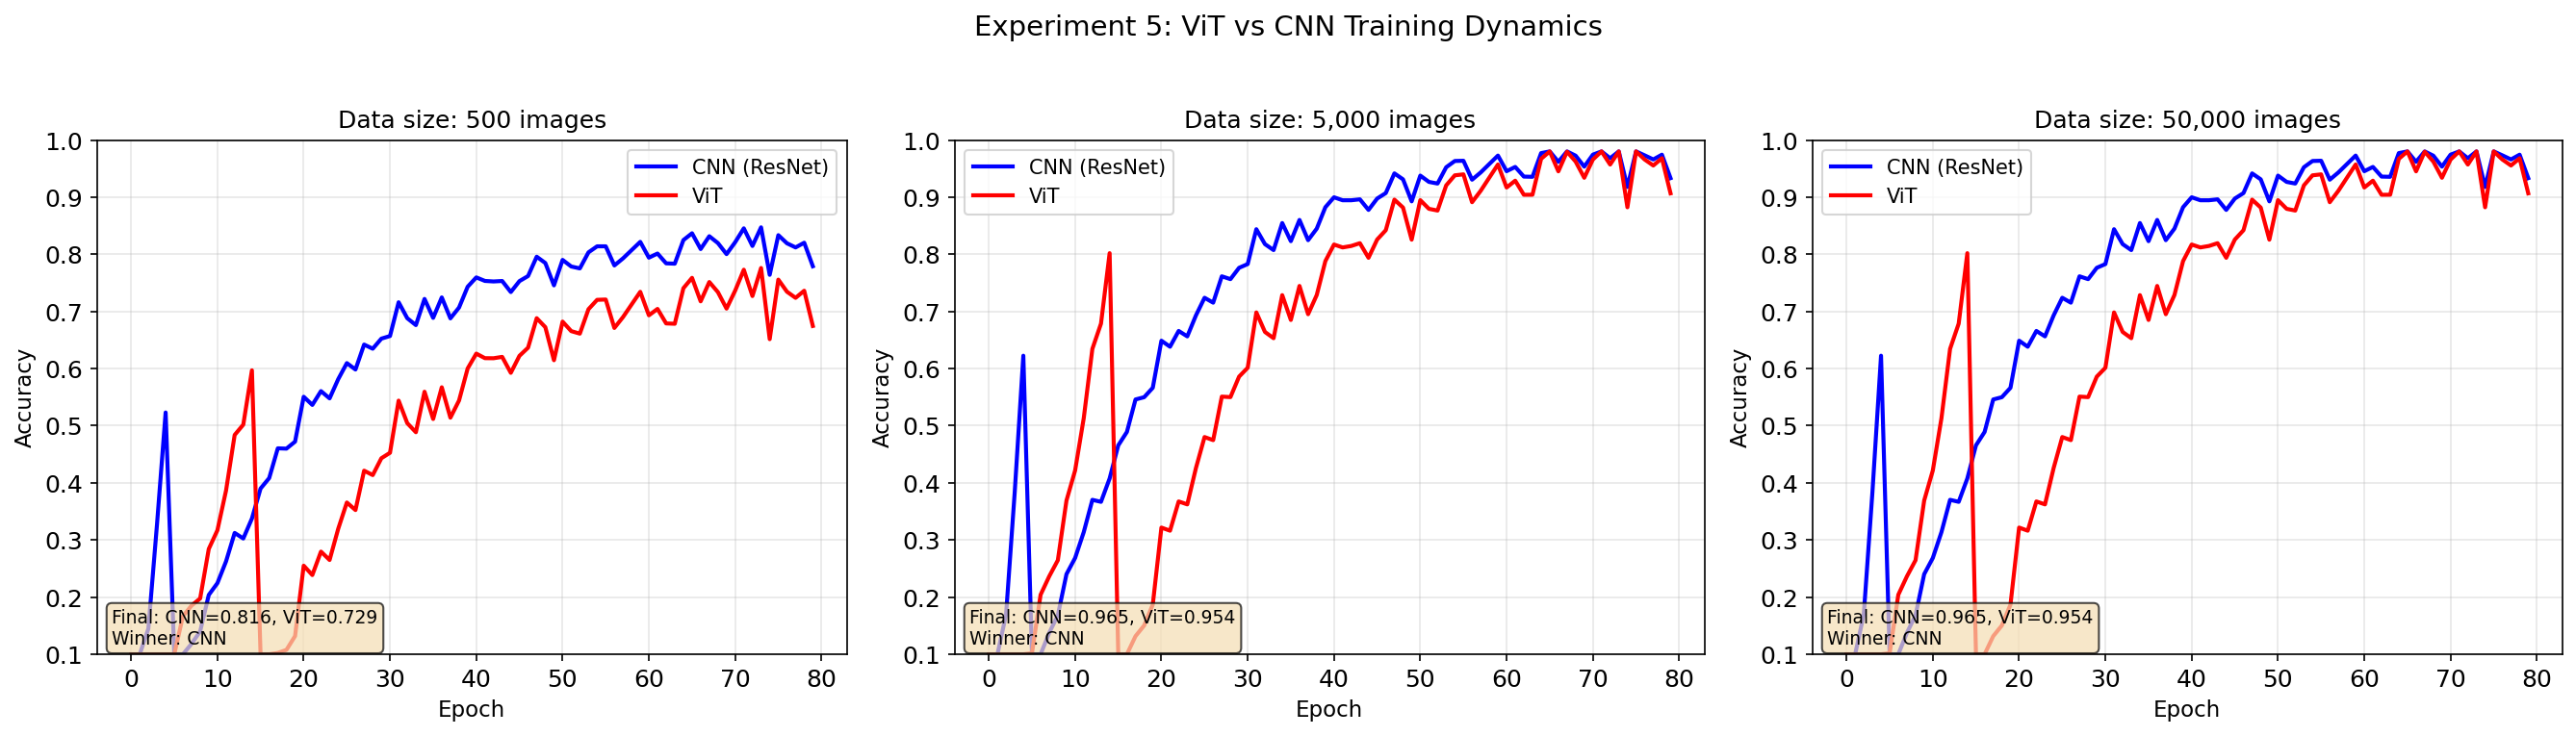

In [41]:
# Experiment 5: ViT vs CNN training dynamics simulation
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def simulate_training(model_type, data_size, epochs=100):
    """Simulate training curves for ViT vs CNN."""
    # CNN: benefits from inductive bias (faster convergence on small data)
    # ViT: more flexible but needs more data
    if model_type == 'CNN':
        base_acc = 0.65 + 0.25 * np.log(data_size / 100) / np.log(10)
        warmup = 5
        noise = 0.02
    else:  # ViT
        base_acc = 0.50 + 0.35 * np.log(data_size / 100) / np.log(10)
        warmup = 15
        noise = 0.03
    
    base_acc = np.clip(base_acc, 0.3, 0.98)
    
    accs = []
    for epoch in range(epochs):
        if epoch < warmup:
            progress = (epoch / warmup) ** 2
        else:
            progress = 1 - np.exp(-(epoch - warmup) / 15)
        
        acc = base_acc * progress + np.random.randn() * noise
        acc = np.clip(acc, 0.1, 0.98)
        accs.append(acc)
    
    return accs

# Compare different data sizes
data_sizes = [500, 5000, 50000]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, ds in enumerate(data_sizes):
    ax = axes[idx]
    np.random.seed(42)
    cnn_accs = simulate_training('CNN', ds, epochs=80)
    np.random.seed(42)
    vit_accs = simulate_training('ViT', ds, epochs=80)
    
    ax.plot(cnn_accs, 'b-', linewidth=2, label='CNN (ResNet)')
    ax.plot(vit_accs, 'r-', linewidth=2, label='ViT')
    ax.set_title(f'Data size: {ds:,} images', fontsize=12)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.legend(fontsize=10)
    ax.set_ylim(0.1, 1.0)
    ax.grid(True, alpha=0.3)
    
    final_cnn = np.mean(cnn_accs[-10:])
    final_vit = np.mean(vit_accs[-10:])
    winner = 'CNN' if final_cnn > final_vit else 'ViT'
    ax.text(0.02, 0.02, f'Final: CNN={final_cnn:.3f}, ViT={final_vit:.3f}\nWinner: {winner}',
            transform=ax.transAxes, fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('Experiment 5: ViT vs CNN Training Dynamics', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb7_exp_vit_vs_cnn.png', dpi=150)
plt.show()
print("Figure saved: nb7_exp_vit_vs_cnn.png")
print("\nKey insight: ViT needs more data to overcome lack of inductive bias!")


---
# 实验总结

### 关键发现

1. **Attention是强大的全局建模工具**
   - 每个位置可以直接关注任意其他位置
   - 通过Q/K/V矩阵实现灵活的信息聚合
   - 多头注意力可以同时捕获多种模式

2. **位置编码不可或缺**
   - Self-Attention本身是置换不变的
   - 正弦编码提供多尺度位置信号
   - ViT使用可学习编码,效果更好

3. **ViT的架构优势**
   - 无CNN归纳偏置,更灵活
   - 第一层就是全局感受野
   - 需要更多训练数据来发挥优势

4. **计算复杂度权衡**
   - Attention复杂度: $O(N^2 \cdot d)$ (N为序列长度)
   - Patch大小影响序列长度和计算量
   - 小patch → 更细粒度但计算量大
   - 大patch → 计算高效但可能丢失细节

### 设计原则
| 组件 | 作用 | 关键参数 |
|------|------|---------|
| Patch Embedding | 图像→序列 | patch_size, d_model |
| Multi-Head Attention | 全局信息聚合 | n_heads, d_k |
| Positional Encoding | 位置信号 | 编码类型, max_len |
| FFN | 非线性变换 | d_ff (通常4*d_model) |
| LayerNorm | 训练稳定 | Pre-Norm vs Post-Norm |
| Residual Connection | 梯度流动 | 所有子层都有 |


---
# 作业

## 作业1: 实现带Mask的Cross-Attention

**任务**: 实现Cross-Attention (Q来自一个序列, K/V来自另一个序列), 并支持mask。

**要求**:
1. 修改 scaled_dot_product_attention 函数, 支持Q和K/V来自不同序列
2. 实现padding mask (忽略指定位置)
3. 实现causal mask (只看当前及之前位置)
4. 测试: Q长度=5, K/V长度=8, mask前3个位置
5. 可视化带mask和不带mask的注意力权重对比

**提示**:
- Cross-Attention的scores形状为 (seq_q, seq_kv)
- mask需要匹配scores的形状

---

## 作业2: 分析ViT的注意力可解释性

**任务**: 通过分析ViT的注意力权重,理解模型如何做分类决策。

**要求**:
1. 使用本notebook中的ViT实现, 在合成图像上运行
2. 提取CLS token在最后一层对所有patch的注意力权重
3. 将注意力权重映射回图像空间 (reshape为patch grid)
4. 对比不同输入图像的注意力热图
5. 分析: 模型关注了哪些区域?是否合理?

**评估**: 
- 生成3张不同输入图像的注意力热图
- 写200字分析: ViT的注意力是否具有可解释性?

---

## 作业3: 对比不同位置编码方案

**任务**: 设计实验对比正弦位置编码和可学习位置编码的效果。

**要求**:
1. 实现第三种位置编码: 相对位置编码 (使用距离的指数衰减)
2. 在相同的ViT架构上, 分别使用三种位置编码
3. 在合成分类任务上训练 (200 epochs)
4. 记录训练损失和验证准确率
5. 分析每种编码的优缺点

**预期结果**:
- 正弦编码: 无需学习,适合短序列
- 可学习编码: 灵活但可能过拟合
- 相对编码: 对位置变化更鲁棒

**提交**: 代码 + 对比图表 + 分析报告 (300字以内)


---
# 参考文献

1. **Attention Is All You Need**: Vaswani, A., et al. (2017). *Attention Is All You Need*. NeurIPS.
   - 提出Transformer架构, Self-Attention, Multi-Head Attention, 位置编码

2. **ViT**: Dosovitskiy, A., et al. (2020). *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale*. ICLR 2021.
   - 将Transformer应用于视觉, 提出Patch Embedding, 证明ViT在大数据上的优越性

3. **BERT**: Devlin, J., et al. (2018). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. arXiv:1810.04805.
   - Transformer在NLP预训练中的成功应用

4. **DeiT**: Touvron, H., et al. (2021). *Training Data-Efficient Image Transformers & Distillation Through Attention*. ICML.
   - 解决ViT数据效率问题, 通过知识蒸馏在小数据上训练ViT

5. **Swin Transformer**: Liu, Z., et al. (2021). *Swin Transformer: Hierarchical Vision Transformer using Shifted Windows*. ICCV.
   - 提出层次化Transformer, 解决ViT计算复杂度问题

6. **Layer Normalization**: Ba, J. L., Kiros, J. R., & Hinton, G. E. (2016). *Layer Normalization*. arXiv:1607.06450.
   - LayerNorm的提出, 替代BatchNorm用于Transformer

7. **CS231n Course**: Johnson, J. & Fei-Fei, L. *CS231n: Convolutional Neural Networks for Visual Recognition*. Stanford University.

---

*本notebook由CS231n课程材料启发, 所有代码实现仅使用NumPy和Matplotlib, 可独立运行。*


---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[lucidrains/vit-pytorch](https://github.com/lucidrains/vit-pytorch)** (25503 stars): Vision Transformer PyTorch 实现（最热门）
  - 仓库地址: https://github.com/lucidrains/vit-pytorch

- **[jeonsworld/ViT-pytorch](https://github.com/jeonsworld/ViT-pytorch)** (2161 stars): ViT 论文官方 PyTorch 复现
  - 仓库地址: https://github.com/jeonsworld/ViT-pytorch

- **[jacobgil/vit-explain](https://github.com/jacobgil/vit-explain)** (1099 stars): ViT 可解释性工具（注意力可视化）
  - 仓库地址: https://github.com/jacobgil/vit-explain


> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现。

